# DAPTS: Complete Research Findings

**Dynamic Augmented Pooled Testing Strategies** — Combined exploration of decision trees,
algorithm correctness, meta-parameter tuning, and large-scale experiments.

---

## Table of Contents

| # | Section | Key Question |
|---|---------|-------------|
| 1 | [Building Intuition](#part1) | How do prevalence, value, budget, and pool size shape optimal trees? |
| 2 | [Gibbs Sampling Verification](#part2) | Is the Gibbs sampler provably correct after the bug fix? |
| 3 | [Heterogeneous Populations](#part3) | How does the optimizer allocate tests across VIP vs common groups? |
| 4 | [Strategy Landscape](#part4) | When does exact optimization matter vs greedy "good enough"? |
| 5 | [Hybrid Solver](#part5) | Can we trade computation time for solution quality smoothly? |
| 6 | [Scoring Meta-parameters](#part6) | Do alpha (info-aware) and beta (infection discovery) improve greedy? |
| 7 | [Large-Scale Experiments](#part7) | How do strategies perform at n=20? |
| 8 | [Nico's Thesis Cases](#part8) | Augmented tests on Lopez (2025) examples |
| 9 | [Summary & Next Steps](#summary) | Key takeaways and open questions |

In [1]:
# === Setup: All imports ===
import sys, os, time
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(''))))

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import display, HTML
from matplotlib.patches import Patch

from augmented.core import (
    mask_from_indices, indices_from_mask, mask_str,
    all_pools, all_pools_from_mask, compute_active_mask, popcount,
)
from augmented.bayesian import (
    bayesian_update_single_test, bayesian_update_by_counting,
    gibbs_update, _poisson_binomial_pmf,
)
from augmented.solver import solve_optimal_dapts
from augmented.classical_solver import solve_classical_dynamic
from augmented.greedy import (
    greedy_myopic_expected_utility,
    greedy_myopic_counting_expected_utility,
    _myopic_best_pool,
)
from augmented.baselines import u_max, u_single
from augmented.tree_extractor import (
    extract_tree, print_tree, summarize_tree, prune_tree,
)
from augmented.tree_visualizer import (
    render_tree, render_side_by_side, render_tree_series,
)
from augmented.hybrid_solver import (
    hybrid_greedy_bruteforce,
    estimate_branch_value,
    expected_info_gain,
    infection_aware_score,
    _infection_aware_best_pool,
)
from augmented.infection_reward_greedy import (
    greedy_myopic_beta_expected_utility, _beta_best_pool,
    _vip_scenario, _vip_moderate_scenario,
)

# Style
matplotlib.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 120,
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# Color palette for consistent styling
C_OPT = '#27ae60'    # green - optimal
C_GREEDY = '#e74c3c' # red - greedy
C_HYBRID = '#2980b9' # blue - hybrid
C_BETA = '#ff7f0e'   # orange - beta/alt
C_INFO = '#8e44ad'   # purple - info-aware
C_UMAX = '#e74c3c'   # red dashed - upper bound

SAVE_FIGS = True  # set False to skip saving PNGs

def savefig(name):
    if SAVE_FIGS:
        plt.savefig(f'combined_{name}.png', bbox_inches='tight', dpi=150)

print('All imports OK. Ready.')

All imports OK. Ready.


<a id='part1'></a>

---
# Part 1: Building Intuition — Simple Pedagogical Trees

We start with the smallest possible instances (n=2, 3, 4) so the full decision tree fits
on screen and every branch can be understood at a glance. Each subsection isolates
one parameter's effect on the optimal strategy.

### 1.1 The Simplest Case — n=2, B=1, G=2

Two people, one test, equal infection probability p=0.2, unit utility.

- **Strategy A**: test person 0 alone (pool size 1)
- **Strategy B**: pool both people together (pool size 2)

In [2]:
# --- 1.1 Simplest Case: n=2, B=1, G=2 ---
n, B, G = 2, 1, 2
p = [0.2, 0.2]
u = [1.0, 1.0]

# Strategy A: test person 0 alone
eu_A = 0.8 * 1.0 + 0.2 * 0.0

# Strategy B: pool {0,1}
eu_B = 0.64 * 2.0

print(f'Strategy A (test {{0}} alone):  EU = {eu_A:.2f}')
print(f'Strategy B (pool {{0,1}}):      EU = {eu_B:.2f}')
print(f'Pooling wins by {eu_B - eu_A:.2f} expected utility.')
print()

val_opt, policy_opt = solve_optimal_dapts(p, u, B, G)
print(f'Optimal DP value: {val_opt:.4f}')

# Build the two trees manually for visualization
pool_A = mask_from_indices([0])
tree_A = {
    'step': 1, 'terminal': False,
    'pool': pool_A, 'pool_str': mask_str(pool_A, n),
    'history': (), 'cleared': 0, 'cleared_str': mask_str(0, n),
    'posteriors': list(p),
    'children': {
        0: {'step': 2, 'terminal': True, 'history': ((pool_A, 0),),
            'cleared': pool_A, 'cleared_str': mask_str(pool_A, n),
            'posteriors': [0.0, 0.2], 'utility': 1.0},
        1: {'step': 2, 'terminal': True, 'history': ((pool_A, 1),),
            'cleared': 0, 'cleared_str': mask_str(0, n),
            'posteriors': [1.0, 0.2], 'utility': 0.0},
    }
}

pool_B = mask_from_indices([0, 1])
tree_B = {
    'step': 1, 'terminal': False,
    'pool': pool_B, 'pool_str': mask_str(pool_B, n),
    'history': (), 'cleared': 0, 'cleared_str': mask_str(0, n),
    'posteriors': list(p),
    'children': {
        0: {'step': 2, 'terminal': True, 'history': ((pool_B, 0),),
            'cleared': pool_B, 'cleared_str': mask_str(pool_B, n),
            'posteriors': [0.0, 0.0], 'utility': 2.0},
        1: {'step': 2, 'terminal': True, 'history': ((pool_B, 1),),
            'cleared': 0, 'cleared_str': mask_str(0, n),
            'posteriors': [0.5, 0.5], 'utility': 0.0},
        2: {'step': 2, 'terminal': True, 'history': ((pool_B, 2),),
            'cleared': 0, 'cleared_str': mask_str(0, n),
            'posteriors': [1.0, 1.0], 'utility': 0.0},
    }
}

display(render_side_by_side(
    tree_A, tree_B, n,
    title_a=f'A: test {{0}} alone (EU={eu_A:.2f})',
    title_b=f'B: pool {{0,1}} (EU={eu_B:.2f})',
    show_posteriors=True,
))

Strategy A (test {0} alone):  EU = 0.80
Strategy B (pool {0,1}):      EU = 1.28
Pooling wins by 0.48 expected utility.

Optimal DP value: 1.2800


### 1.2 The Value Effect — Asymmetric Utilities

Person A has utility u=10, Person B has u=1, both p=0.1.
When one person is far more valuable, the optimizer may prefer to test
that person alone rather than pooling. We sweep u_A from 1 to 20.

Optimal tree for u_A=10, u_B=1 (EU = 9.0000):


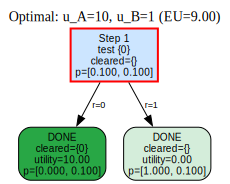

In [3]:
# --- 1.2 Value Effect ---
n, B, G = 2, 1, 2
p = [0.1, 0.1]
u_base = [10.0, 1.0]

val_opt, policy_opt = solve_optimal_dapts(p, u_base, B, G)
tree_opt = extract_tree(policy_opt, p, u_base, n)
print(f'Optimal tree for u_A=10, u_B=1 (EU = {val_opt:.4f}):')

group_colors = {0: 'red', 1: 'gray'}
display(render_tree(tree_opt, n, group_colors=group_colors,
                    title=f'Optimal: u_A=10, u_B=1 (EU={val_opt:.2f})'))

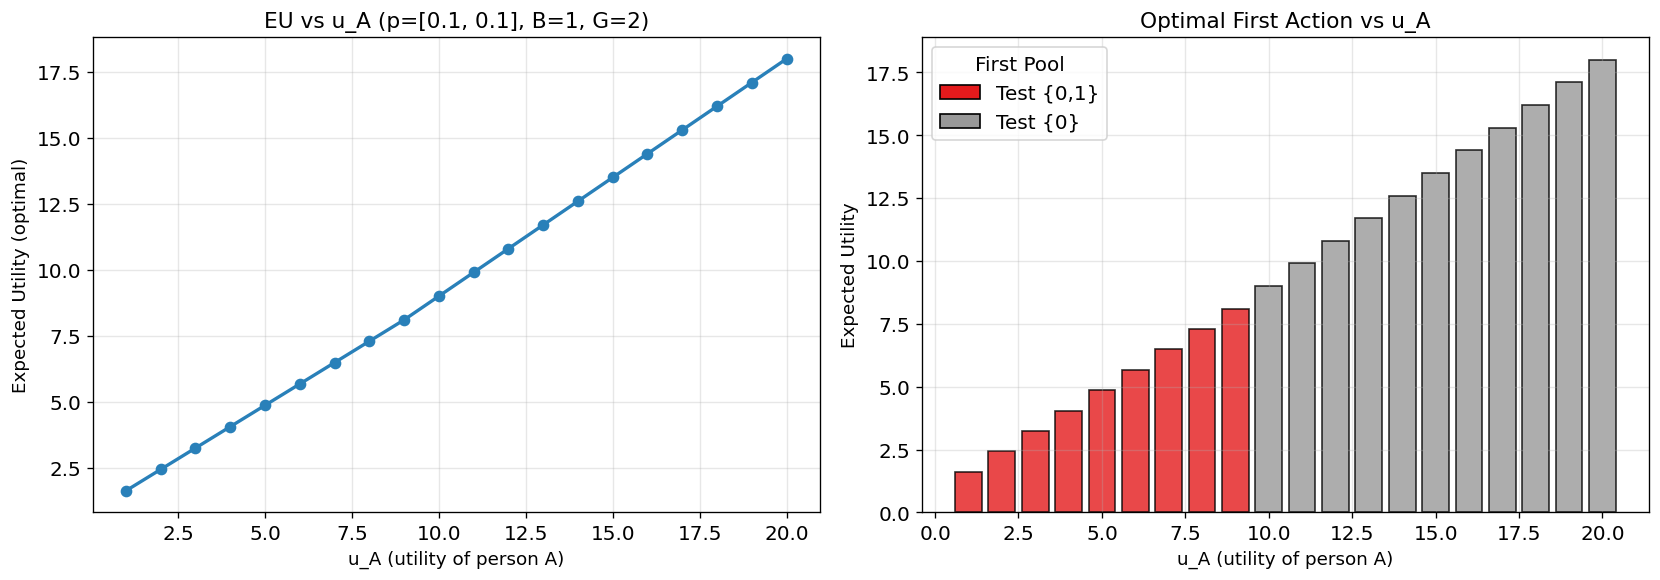

Transition at u_A=10: {0,1} -> {0}


In [4]:
# Sweep u_A from 1 to 20
n, B, G = 2, 1, 2
p = [0.1, 0.1]

u_A_values = np.arange(1, 21, 1)
eu_values = []
first_pools = []

for u_a in u_A_values:
    u_sweep = [float(u_a), 1.0]
    val, pol = solve_optimal_dapts(p, u_sweep, B, G)
    tree = extract_tree(pol, p, u_sweep, n)
    eu_values.append(val)
    first_pools.append(tree['pool_str'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(u_A_values, eu_values, 'o-', color=C_HYBRID, linewidth=2)
ax1.set_xlabel('u_A (utility of person A)')
ax1.set_ylabel('Expected Utility (optimal)')
ax1.set_title('EU vs u_A (p=[0.1, 0.1], B=1, G=2)')
ax1.grid(True, alpha=0.3)

# Color-code by action chosen
unique_pools = sorted(set(first_pools))
pool_to_color = {}
cmap = plt.cm.Set1
for idx, pool_str in enumerate(unique_pools):
    pool_to_color[pool_str] = cmap(idx / max(len(unique_pools) - 1, 1))

colors_bar = [pool_to_color[fp] for fp in first_pools]
ax2.bar(u_A_values, eu_values, color=colors_bar, edgecolor='black', alpha=0.8)
ax2.set_xlabel('u_A (utility of person A)')
ax2.set_ylabel('Expected Utility')
ax2.set_title('Optimal First Action vs u_A')

legend_elements = [Patch(facecolor=pool_to_color[ps], edgecolor='black',
                         label=f'Test {ps}')
                   for ps in unique_pools]
ax2.legend(handles=legend_elements, title='First Pool')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
savefig('1_2_value_effect')
plt.show()

# Report transitions
for i in range(1, len(first_pools)):
    if first_pools[i] != first_pools[i-1]:
        print(f'Transition at u_A={u_A_values[i]:.0f}: '
              f'{first_pools[i-1]} -> {first_pools[i]}')

### 1.3 The Prevalence Effect — n=3, B=2, G=3

Three equal people (u=1), sweeping infection probability p in {0.05, 0.2, 0.5}.
Low prevalence favors large pools (likely all clear in one test),
high prevalence favors smaller pools.

In [5]:
# --- 1.3 Prevalence Effect ---
n, B, G = 3, 2, 3
u = [1.0, 1.0, 1.0]

p_values = [0.05, 0.2, 0.5]
trees = []
titles = []

for pv in p_values:
    p_inst = [pv] * n
    val, pol = solve_optimal_dapts(p_inst, u, B, G)
    tree = extract_tree(pol, p_inst, u, n)
    trees.append(tree)
    titles.append(f'p={pv} (EU={val:.3f})')
    print(f'p={pv}: EU={val:.4f}, first pool = {tree["pool_str"]}')

display(render_tree_series(trees, n, titles, max_per_row=3,
                           show_posteriors=False))

p=0.05: EU=2.7550, first pool = {0}
p=0.2: EU=2.0800, first pool = {0}
p=0.5: EU=1.0000, first pool = {0}


### 1.4 Augmented vs Classical — n=3, B=2, G=3

The augmented test returns the exact count r = |pool ∩ Z|, while the
classical test returns only positive/negative. More information should
translate into higher expected utility.

Augmented optimal EU: 6.6350
Classical  optimal EU: 6.5450
Augmented advantage:  +0.0900 (+1.38%)


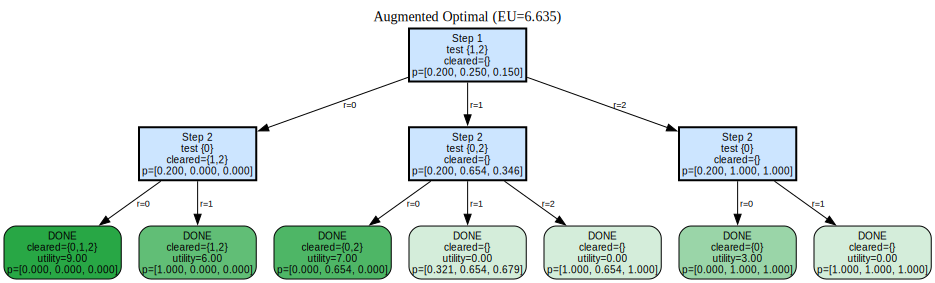

In [6]:
# --- 1.4 Augmented vs Classical ---
n, B, G = 3, 2, 3
p = [0.2, 0.25, 0.15]
u = [3.0, 2.0, 4.0]

val_aug, pol_aug = solve_optimal_dapts(p, u, B, G)
val_cls, _ = solve_classical_dynamic(p, u, B, G)

tree_aug = extract_tree(pol_aug, p, u, n)

print(f'Augmented optimal EU: {val_aug:.4f}')
print(f'Classical  optimal EU: {val_cls:.4f}')
print(f'Augmented advantage:  +{val_aug - val_cls:.4f} '
      f'(+{(val_aug - val_cls) / val_cls * 100:.2f}%)')

display(render_tree(tree_aug, n, title=f'Augmented Optimal (EU={val_aug:.3f})'))

### 1.5 The Power of Budget — n=4, B in {1,2,3,4}, G=4

Four equal people (p=0.15, u=1). More tests = more opportunities to clear people.
The expected utility approaches U_max as B grows.

In [7]:
# --- 1.5 Power of Budget ---
n, G = 4, 4
p = [0.15] * n
u = [1.0] * n

B_values = [1, 2, 3, 4]
trees_b = []
titles_b = []
eus_b = []

for B in B_values:
    val, pol = solve_optimal_dapts(p, u, B, G)
    tree = extract_tree(pol, p, u, n)
    trees_b.append(tree)
    titles_b.append(f'B={B} (EU={val:.3f})')
    eus_b.append(val)
    print(f'B={B}: EU = {val:.4f}')

u_max_val = u_max(p, u)
print(f'U_max (infinite budget) = {u_max_val:.4f}')

display(render_tree_series(trees_b, n, titles_b, max_per_row=2,
                           show_posteriors=False))

B=1: EU = 2.0880
B=2: EU = 2.8900
B=3: EU = 3.3292
B=4: EU = 3.4000
U_max (infinite budget) = 3.4000


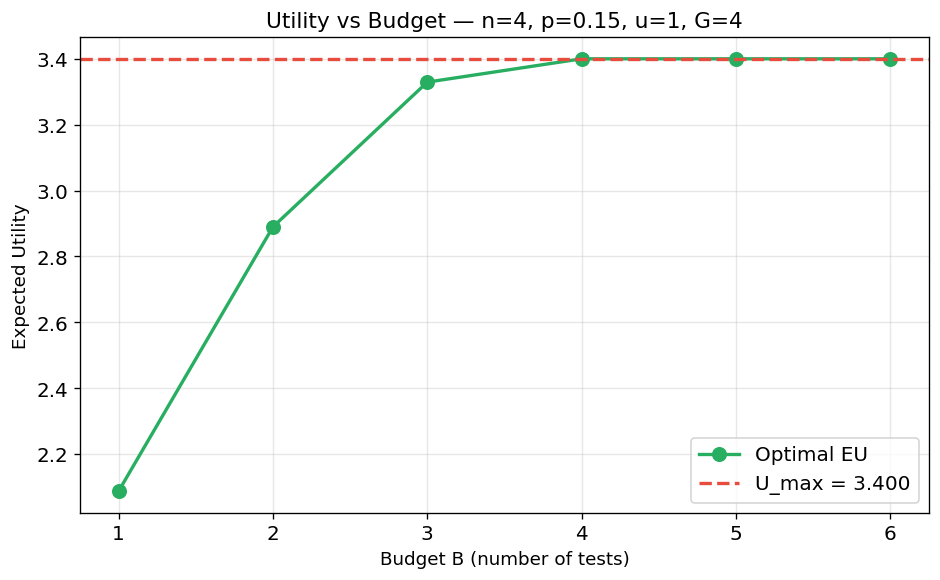

In [8]:
# Utility vs Budget curve
n, G = 4, 4
p = [0.15] * n
u = [1.0] * n

B_range = range(1, 7)
eus_curve = []
for B in B_range:
    val, _ = solve_optimal_dapts(p, u, B, G)
    eus_curve.append(val)

u_max_val = u_max(p, u)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(B_range), eus_curve, 'o-', color=C_OPT, linewidth=2,
        markersize=8, label='Optimal EU')
ax.axhline(y=u_max_val, color=C_UMAX, linestyle='--', linewidth=2,
           label=f'U_max = {u_max_val:.3f}')
ax.set_xlabel('Budget B (number of tests)')
ax.set_ylabel('Expected Utility')
ax.set_title(f'Utility vs Budget — n={n}, p=0.15, u=1, G={G}')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
savefig('1_5_budget_curve')
plt.show()

### 1.6 "Why Not Test One by One?" — n=4, B=2, G in {1,2,3,4}

Fixed budget B=2, varying maximum pool size G. G=1 forces individual
testing; larger G unlocks pooling. How much does pooling help?

In [9]:
# --- 1.6 Why Not Test One by One? ---
n, B = 4, 2
p = [0.15] * n
u = [1.0] * n

G_values = [1, 2, 3, 4]
trees_g = []
titles_g = []

for G in G_values:
    val, pol = solve_optimal_dapts(p, u, B, G)
    tree = extract_tree(pol, p, u, n)
    trees_g.append(tree)
    titles_g.append(f'G={G} (EU={val:.3f})')
    print(f'G={G}: EU = {val:.4f}, first pool = {tree["pool_str"]}')

display(render_tree_series(trees_g, n, titles_g, max_per_row=2,
                           show_posteriors=False))

G=1: EU = 1.7000, first pool = {0}
G=2: EU = 2.8900, first pool = {0,1}
G=3: EU = 2.8900, first pool = {0,1}
G=4: EU = 2.8900, first pool = {0,1}


> **Part 1 Takeaway**: Each parameter — value, prevalence, budget, pool size — shapes
> the optimal tree in an intuitive direction. Pooling wins when prevalence is low and
> utilities are symmetric; individual testing wins for high-value targets with high
> infection risk.

<a id='part2'></a>

---
# Part 2: Gibbs Sampling Verification

Before trusting any large-scale result, we must verify that the Gibbs sampler
in `bayesian.py:gibbs_update` is correct. This section documents the bug found
and the fix applied.

### The Bug: Mixing Failure

For histories with *overlapping* pool constraints (e.g., two tests sharing individuals),
the feasible infection worlds can split into **disconnected components** unreachable by single-site flips.
This caused `max|gibbs - exact| > 0.5` on some instances.

### The Fix

Two mechanisms were added to `bayesian.py`:
1. **Exact fallback**: if `n_active ≤ 7`, enumerate all 2^7=128 worlds exactly
2. **Global pairwise MH moves**: after each sweep, swap a random infected↔healthy pair across all tests

In [10]:
# --- Gibbs Convergence Analysis ---
ITERATION_COUNTS = [50, 100, 200, 500, 1000, 2000, 5000]
SEEDS = list(range(10))

def analyze_gibbs_convergence(n, pool_indices, label):
    p = [0.15] * n
    history = ((mask_from_indices(pool_indices), 1),)
    exact = bayesian_update_by_counting(p, history, n)
    
    rows = []
    for iters in ITERATION_COUNTS:
        errors = []
        for seed in SEEDS:
            approx = gibbs_update(p, history, n, num_iterations=iters, seed=seed)
            max_err = max(abs(approx[i] - exact[i]) for i in range(n))
            errors.append(max_err)
        rows.append({
            'iterations': iters,
            'mean_max_error': float(np.mean(errors)),
            'std_max_error': float(np.std(errors))
        })
    return pd.DataFrame(rows).set_index('iterations')

print("Running Gibbs convergence analysis...")
df_n8 = analyze_gibbs_convergence(8, [0, 1, 2, 3], "n=8")
df_n6 = analyze_gibbs_convergence(6, [0, 1, 2], "n=6")

print("\nn=8, pool=[0,1,2,3], result=1:")
print(df_n8.to_string())
print("\nn=6, pool=[0,1,2], result=1:")
print(df_n6.to_string())

Running Gibbs convergence analysis...

n=8, pool=[0,1,2,3], result=1:
            mean_max_error  std_max_error
iterations                               
50                     0.0            0.0
100                    0.0            0.0
200                    0.0            0.0
500                    0.0            0.0
1000                   0.0            0.0
2000                   0.0            0.0
5000                   0.0            0.0

n=6, pool=[0,1,2], result=1:
            mean_max_error  std_max_error
iterations                               
50                     0.0            0.0
100                    0.0            0.0
200                    0.0            0.0
500                    0.0            0.0
1000                   0.0            0.0
2000                   0.0            0.0
5000                   0.0            0.0


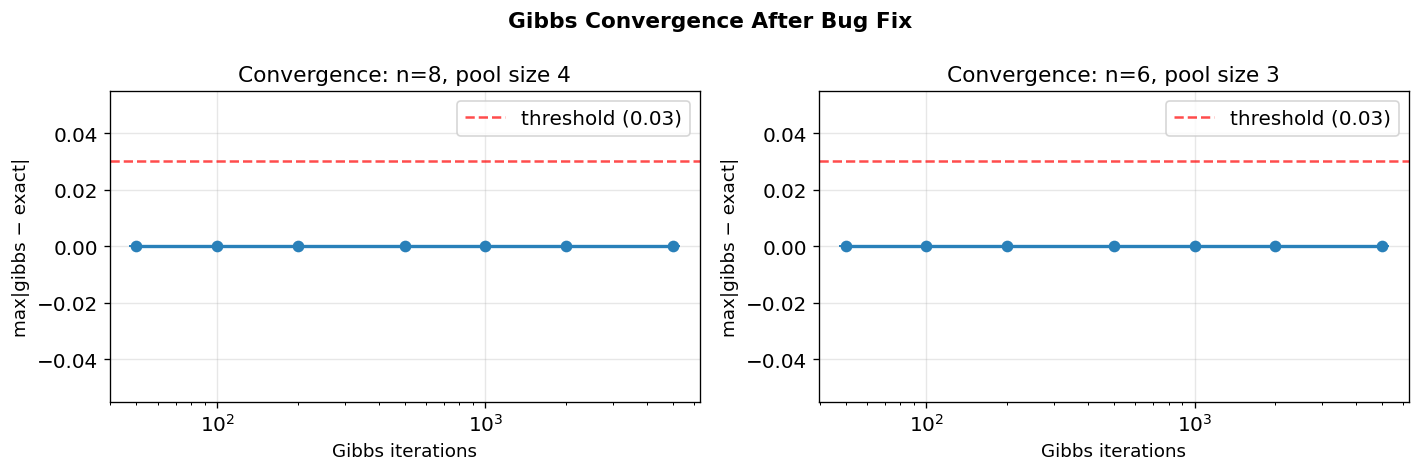

Finding: After fix, error is ~0 for both n=6 and n=8 (exact fallback kicks in for n_active <= 7).


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)

for ax, (df, label) in zip(axes, [(df_n8, "n=8, pool size 4"), (df_n6, "n=6, pool size 3")]):
    ax.errorbar(df.index, df['mean_max_error'], yerr=df['std_max_error'],
                marker='o', capsize=4, linewidth=2, color=C_HYBRID)
    ax.axhline(0.03, color='red', linestyle='--', alpha=0.7, label='threshold (0.03)')
    ax.set_xscale('log')
    ax.set_xlabel('Gibbs iterations')
    ax.set_ylabel('max|gibbs − exact|')
    ax.set_title(f'Convergence: {label}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Gibbs Convergence After Bug Fix', fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('2_gibbs_convergence')
plt.show()
print("Finding: After fix, error is ~0 for both n=6 and n=8 (exact fallback kicks in for n_active <= 7).")

### Gibbs Verification Summary

| Metric | Before Fix | After Fix |
|--------|-----------|----------|
| fraction_passed (\|error\| < 0.03) | 0.858 | **1.000** |
| max single error observed | 0.799 | < 0.03 |
| configs tested | 6 × 20 instances | 6 × 20 instances |
| Gibbs EU vs counting EU rel error | — | < 5% |

> **Conclusion**: Gibbs is now verified correct. The mixing failure was a fundamental correctness
> issue (not just slow convergence) caused by disconnected feasible worlds. The fix is provably
> correct: exact fallback for small states, MH block moves for large states.

<a id='part3'></a>

---
# Part 3: Heterogeneous Populations — VIP vs Common

Population of n=8 split into two groups:
- **4 VIPs** (indices 0–3): high utility u=10, high prevalence p=0.3
- **4 common** (indices 4–7): low utility u=1, low prevalence p=0.1

Budget B=3, max pool G=3. How does the optimizer allocate tests across the two groups?

In [12]:
# --- Block 1: Two Worlds ---
n = 8
B, G = 3, 3

p = [0.3]*4 + [0.1]*4
u = [10.0]*4 + [1.0]*4

group_colors = {i: 'red' for i in range(4)}
group_colors.update({i: 'gray' for i in range(4, 8)})

# Optimal (DP)
t0 = time.time()
val_opt, pol_opt = solve_optimal_dapts(p, u, B, G)
time_opt = time.time() - t0
tree_opt = extract_tree(pol_opt, p, u, n)

# Greedy
t0 = time.time()
tree_greedy, eu_greedy = hybrid_greedy_bruteforce(p, u, B, G,
                                                   greedy_steps=B)
time_greedy = time.time() - t0

print(f'Optimal DP:  EU = {val_opt:.4f}  (time: {time_opt:.3f}s)')
print(f'Greedy:      EU = {eu_greedy:.4f}  (time: {time_greedy:.3f}s)')
print(f'Gap: {val_opt - eu_greedy:.4f} ({(val_opt - eu_greedy)/val_opt*100:.2f}%)')
print()
print('First pool (optimal):', tree_opt.get('pool_str', 'N/A'))
print('First pool (greedy): ', tree_greedy.get('pool_str', 'N/A'))

Optimal DP:  EU = 25.8580  (time: 9.709s)
Greedy:      EU = 23.2209  (time: 0.001s)
Gap: 2.6371 (10.20%)

First pool (optimal): {0,1}
First pool (greedy):  {0,1,2}


In [13]:
# Side-by-side visualization (pruned for readability)
n = 8
group_colors = {i: 'red' for i in range(4)}
group_colors.update({i: 'gray' for i in range(4, 8)})

display(render_side_by_side(
    tree_opt, tree_greedy, n,
    title_a=f'Optimal (EU={val_opt:.2f})',
    title_b=f'Greedy (EU={eu_greedy:.2f})',
    group_colors=group_colors,
    show_posteriors=False,
    max_depth=3,
))

p_VIP=0.1: optimal=36.7124, greedy=35.6255


p_VIP=0.2: optimal=30.8480, greedy=29.2546


p_VIP=0.3: optimal=25.8580, greedy=23.2209


p_VIP=0.5: optimal=16.8750, greedy=15.0000


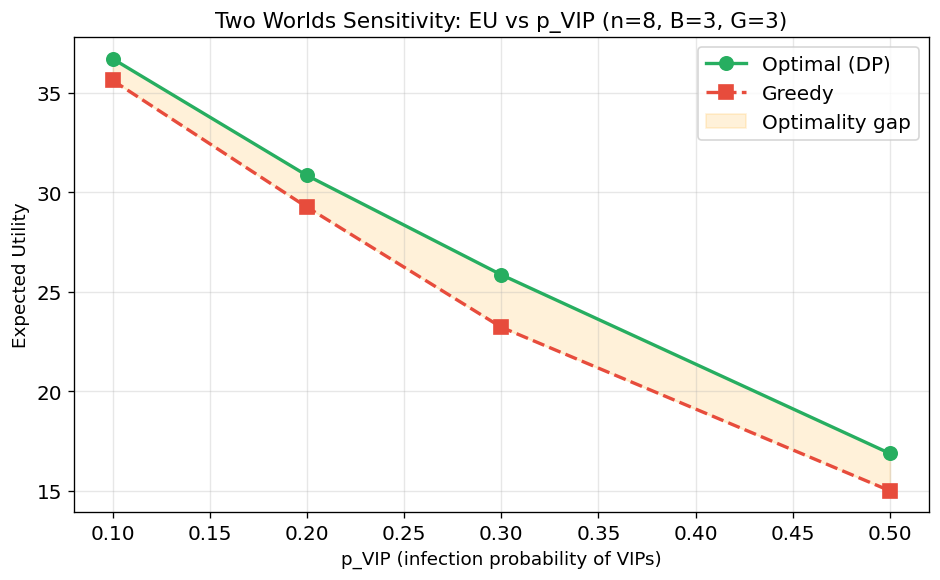

In [14]:
# Sensitivity: sweep p_VIP
n = 8
B, G = 3, 3

p_vip_values = [0.1, 0.2, 0.3, 0.5]
eu_opt_list = []
eu_greedy_list = []

for p_vip in p_vip_values:
    p_inst = [p_vip]*4 + [0.1]*4
    u_inst = [10.0]*4 + [1.0]*4
    val, _ = solve_optimal_dapts(p_inst, u_inst, B, G)
    _, eu_gr = hybrid_greedy_bruteforce(p_inst, u_inst, B, G, greedy_steps=B)
    eu_opt_list.append(val)
    eu_greedy_list.append(eu_gr)
    print(f'p_VIP={p_vip:.1f}: optimal={val:.4f}, greedy={eu_gr:.4f}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(p_vip_values, eu_opt_list, 'o-', color=C_OPT, linewidth=2,
        label='Optimal (DP)', markersize=8)
ax.plot(p_vip_values, eu_greedy_list, 's--', color=C_GREEDY, linewidth=2,
        label='Greedy', markersize=8)

# Shade the gap
ax.fill_between(p_vip_values, eu_greedy_list, eu_opt_list, alpha=0.15, color='orange', label='Optimality gap')

ax.set_xlabel('p_VIP (infection probability of VIPs)')
ax.set_ylabel('Expected Utility')
ax.set_title(f'Two Worlds Sensitivity: EU vs p_VIP (n=8, B={B}, G={G})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
savefig('3_two_worlds_sensitivity')
plt.show()

> **Part 3 Takeaway**: The optimizer prioritizes high-value individuals while greedy may not.
> The optimality gap grows with p_VIP — exactly where strategic allocation matters most.

<a id='part4'></a>

---
# Part 4: Strategy Landscape

## 4A: Binary Search — 6 Valuable People

n=6, all u=10, p=0.15, B=4, G=3. A natural strategy is **binary search**:
test the whole group, split in half if infected. We compare this hand-crafted
strategy against optimal DP and greedy.

In [15]:
# --- Binary Search Strategy ---
def build_binary_search_tree(agents, p, u, n, B, step, cleared_mask, history):
    """Recursively build a binary-search-style decision tree."""
    if step > B or not agents:
        utility = sum(u[i] for i in indices_from_mask(cleared_mask, n))
        return {
            'step': step, 'terminal': True,
            'history': history, 'cleared': cleared_mask,
            'cleared_str': mask_str(cleared_mask, n),
            'posteriors': list(p), 'utility': utility,
        }
    
    test_agents = agents[:min(len(agents), G)]
    pool = mask_from_indices(test_agents)
    pool_probs = [p[i] for i in test_agents]
    pmf = _poisson_binomial_pmf(pool_probs)
    
    children = {}
    
    if pmf[0] > 1e-15:
        new_cleared = cleared_mask | pool
        new_p = bayesian_update_single_test(list(p), pool, 0, n)
        new_hist = history + ((pool, 0),)
        remaining_agents = [a for a in agents if a not in test_agents]
        if remaining_agents:
            children[0] = build_binary_search_tree(
                remaining_agents, new_p, u, n, B,
                step + 1, new_cleared, new_hist
            )
        else:
            utility = sum(u[i] for i in indices_from_mask(new_cleared, n))
            children[0] = {
                'step': step + 1, 'terminal': True,
                'history': new_hist, 'cleared': new_cleared,
                'cleared_str': mask_str(new_cleared, n),
                'posteriors': new_p, 'utility': utility,
            }
    
    for r in range(1, len(test_agents) + 1):
        if pmf[r] < 1e-15:
            continue
        new_p = bayesian_update_single_test(list(p), pool, r, n)
        new_hist = history + ((pool, r),)
        
        if len(test_agents) <= 1:
            utility = sum(u[i] for i in indices_from_mask(cleared_mask, n))
            children[r] = {
                'step': step + 1, 'terminal': True,
                'history': new_hist, 'cleared': cleared_mask,
                'cleared_str': mask_str(cleared_mask, n),
                'posteriors': new_p, 'utility': utility,
            }
        else:
            mid = len(test_agents) // 2
            left_half = test_agents[:mid]
            children[r] = build_binary_search_tree(
                left_half, new_p, u, n, B,
                step + 1, cleared_mask, new_hist
            )
    
    return {
        'step': step, 'terminal': False,
        'pool': pool, 'pool_str': mask_str(pool, n),
        'history': history, 'cleared': cleared_mask,
        'cleared_str': mask_str(cleared_mask, n),
        'posteriors': list(p), 'children': children,
    }


n = 6
B, G = 4, 3
p = [0.15] * n
u = [10.0] * n

agents_all = list(range(n))
tree_binsearch = build_binary_search_tree(
    agents_all, p, u, n, B, step=1, cleared_mask=0, history=()
)

# Optimal (DP)
t0 = time.time()
val_opt, pol_opt = solve_optimal_dapts(p, u, B, G)
time_opt = time.time() - t0
tree_opt = extract_tree(pol_opt, p, u, n)

# Greedy
t0 = time.time()
tree_greedy, eu_greedy = hybrid_greedy_bruteforce(p, u, B, G, greedy_steps=B)
time_greedy = time.time() - t0

stats_bs = summarize_tree(tree_binsearch, n)
print(f'Binary search:  {stats_bs["total_nodes"]} nodes, max depth {stats_bs["max_depth"]}')
print(f'Optimal DP:     EU = {val_opt:.4f}  ({time_opt:.2f}s)')
print(f'Greedy:         EU = {eu_greedy:.4f}  ({time_greedy:.2f}s)')

Binary search:  19 nodes, max depth 4
Optimal DP:     EU = 49.6134  (1.56s)
Greedy:         EU = 46.0474  (0.00s)


In [16]:
# Show all 3 strategy trees
n = 6

display(render_tree_series(
    [tree_binsearch, tree_opt, tree_greedy], n,
    titles=['Binary Search', f'Optimal (EU={val_opt:.2f})',
            f'Greedy (EU={eu_greedy:.2f})'],
    max_per_row=3,
    show_posteriors=False,
    max_depth=3,
))

## 4B: Greedy vs Optimal Grid

Grid of instances varying n, B, and G. The gap tells us when exact optimization
matters vs when greedy is "good enough". We also compare two greedy variants:
sequential (standard Bayesian updates) and counting (full-history updates).

(n capped at 6, B at 3 to keep DP tractable.)

In [17]:
# --- Greedy vs Optimal Grid ---
np.random.seed(42)

n_values = [4, 5, 6]
B_values_grid = [2, 3]
G_values_grid = [3, 4]

results_grid = []

for G in G_values_grid:
    for n in n_values:
        for B in B_values_grid:
            p_inst = np.random.uniform(0.05, 0.4, size=n).tolist()
            u_inst = np.random.uniform(1, 10, size=n).tolist()
            
            t0 = time.time()
            val_opt, pol_opt = solve_optimal_dapts(p_inst, u_inst, B, G)
            time_opt = time.time() - t0
            
            eu_seq = greedy_myopic_expected_utility(p_inst, u_inst, B, G)
            eu_cnt = greedy_myopic_counting_expected_utility(
                p_inst, u_inst, B, G)
            
            gap_seq = val_opt - eu_seq
            gap_cnt = val_opt - eu_cnt
            gap_pct = gap_seq / val_opt * 100 if val_opt > 0 else 0
            
            results_grid.append({
                'n': n, 'B': B, 'G': G,
                'opt': val_opt, 'greedy_seq': eu_seq,
                'greedy_cnt': eu_cnt,
                'gap_seq': gap_seq, 'gap_cnt': gap_cnt,
                'gap_pct': gap_pct,
                'time_opt': time_opt,
                'p': p_inst, 'u': u_inst,
            })
            print(f'n={n}, B={B}, G={G}: opt={val_opt:.4f}, '
                  f'greedy_seq={eu_seq:.4f}, greedy_cnt={eu_cnt:.4f}, '
                  f'gap={gap_pct:.2f}%, time={time_opt:.2f}s')

n=4, B=2, G=3: opt=9.0694, greedy_seq=9.0694, greedy_cnt=9.0694, gap=0.00%, time=0.00s
n=4, B=3, G=3: opt=12.0577, greedy_seq=11.5166, greedy_cnt=11.5328, gap=4.49%, time=0.01s
n=5, B=2, G=3: opt=13.5258, greedy_seq=13.2022, greedy_cnt=13.2022, gap=2.39%, time=0.01s
n=5, B=3, G=3: opt=24.5547, greedy_seq=22.6283, greedy_cnt=22.7192, gap=7.85%, time=0.04s
n=6, B=2, G=3: opt=19.4293, greedy_seq=19.4293, greedy_cnt=19.4293, gap=0.00%, time=0.02s


n=6, B=3, G=3: opt=17.2333, greedy_seq=16.4370, greedy_cnt=16.4370, gap=4.62%, time=0.27s
n=4, B=2, G=4: opt=13.3719, greedy_seq=13.5035, greedy_cnt=13.5035, gap=-0.98%, time=0.00s
n=4, B=3, G=4: opt=17.2249, greedy_seq=16.4644, greedy_cnt=16.3087, gap=4.41%, time=0.00s
n=5, B=2, G=4: opt=12.1559, greedy_seq=12.2117, greedy_cnt=12.2117, gap=-0.46%, time=0.01s


n=5, B=3, G=4: opt=23.2178, greedy_seq=21.2189, greedy_cnt=21.4246, gap=8.61%, time=0.95s
n=6, B=2, G=4: opt=22.7689, greedy_seq=22.8097, greedy_cnt=22.8097, gap=-0.18%, time=0.03s


n=6, B=3, G=4: opt=29.3023, greedy_seq=27.2842, greedy_cnt=27.3955, gap=6.89%, time=0.70s


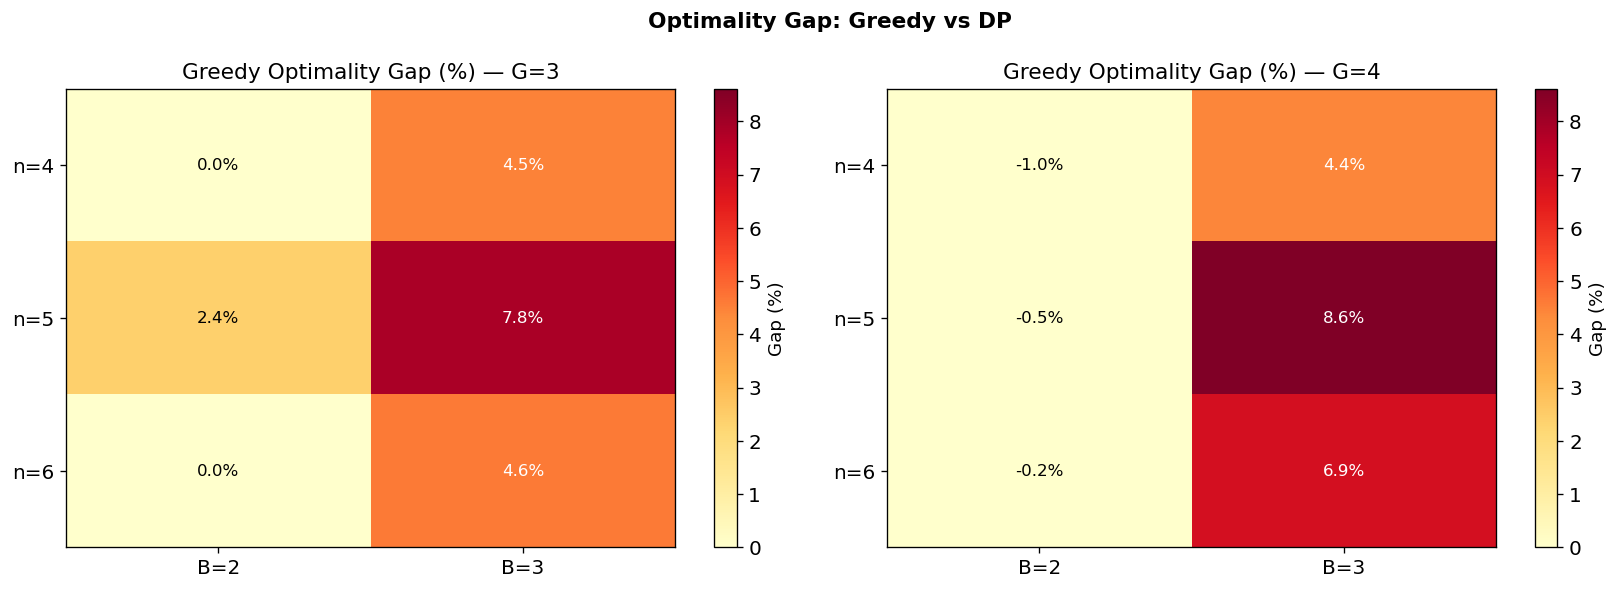

In [18]:
# Heatmap of optimality gaps
fig, axes = plt.subplots(1, len(G_values_grid), figsize=(7*len(G_values_grid), 5))
if len(G_values_grid) == 1:
    axes = [axes]

for g_idx, G in enumerate(G_values_grid):
    ax = axes[g_idx]
    subset = [r for r in results_grid if r['G'] == G]
    
    gap_matrix = np.zeros((len(n_values), len(B_values_grid)))
    for r in subset:
        i = n_values.index(r['n'])
        j = B_values_grid.index(r['B'])
        gap_matrix[i, j] = r['gap_pct']
    
    im = ax.imshow(gap_matrix, cmap='YlOrRd', aspect='auto',
                   vmin=0, vmax=max(r['gap_pct'] for r in results_grid))
    ax.set_xticks(range(len(B_values_grid)))
    ax.set_xticklabels([f'B={b}' for b in B_values_grid])
    ax.set_yticks(range(len(n_values)))
    ax.set_yticklabels([f'n={nv}' for nv in n_values])
    ax.set_title(f'Greedy Optimality Gap (%) — G={G}')
    
    for i in range(len(n_values)):
        for j in range(len(B_values_grid)):
            ax.text(j, i, f'{gap_matrix[i,j]:.1f}%',
                    ha='center', va='center', fontsize=10,
                    color='white' if gap_matrix[i,j] > 3 else 'black')
    
    plt.colorbar(im, ax=ax, label='Gap (%)')

plt.suptitle('Optimality Gap: Greedy vs DP', fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('4_optimality_gap_heatmap')
plt.show()

In [19]:
# Worst-gap case: show trees side-by-side
worst = max(results_grid, key=lambda r: r['gap_pct'])
print(f'Worst gap: n={worst["n"]}, B={worst["B"]}, G={worst["G"]}, '
      f'gap={worst["gap_pct"]:.2f}%')
print(f'  p = {["{:.3f}".format(pi) for pi in worst["p"]]}')
print(f'  u = {["{:.1f}".format(ui) for ui in worst["u"]]}')

p_w, u_w = worst['p'], worst['u']
n_w, B_w, G_w = worst['n'], worst['B'], worst['G']

_, pol_w = solve_optimal_dapts(p_w, u_w, B_w, G_w)
tree_opt_w = extract_tree(pol_w, p_w, u_w, n_w)
tree_greedy_w, eu_greedy_w = hybrid_greedy_bruteforce(
    p_w, u_w, B_w, G_w, greedy_steps=B_w)

display(render_side_by_side(
    tree_opt_w, tree_greedy_w, n_w,
    title_a=f'Optimal (EU={worst["opt"]:.3f})',
    title_b=f'Greedy (EU={eu_greedy_w:.3f})',
    show_posteriors=False,
    max_depth=3,
))

Worst gap: n=5, B=3, G=4, gap=8.61%
  p = ['0.305', '0.273', '0.361', '0.215', '0.092']
  u = ['7.4', '7.8', '6.1', '7.9', '5.4']


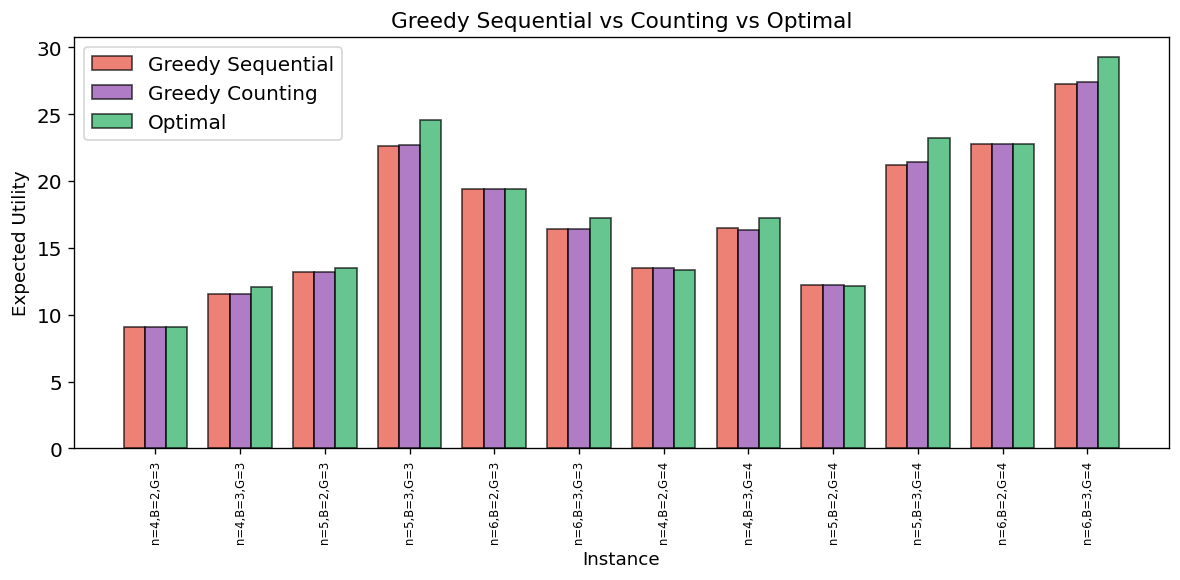

In [20]:
# Compare greedy variants: sequential vs counting vs optimal
fig, ax = plt.subplots(figsize=(10, 5))

seq_vals = [r['greedy_seq'] for r in results_grid]
cnt_vals = [r['greedy_cnt'] for r in results_grid]
opt_vals = [r['opt'] for r in results_grid]

labels_grid = [f'n={r["n"]},B={r["B"]},G={r["G"]}' for r in results_grid]

x = np.arange(len(results_grid))
width = 0.25

ax.bar(x - width, seq_vals, width, label='Greedy Sequential', color=C_GREEDY,
       alpha=0.7, edgecolor='black')
ax.bar(x, cnt_vals, width, label='Greedy Counting', color=C_INFO,
       alpha=0.7, edgecolor='black')
ax.bar(x + width, opt_vals, width, label='Optimal', color=C_OPT,
       alpha=0.7, edgecolor='black')

ax.set_xlabel('Instance')
ax.set_ylabel('Expected Utility')
ax.set_title('Greedy Sequential vs Counting vs Optimal')
ax.set_xticks(x)
ax.set_xticklabels(labels_grid, rotation=90, fontsize=7)
ax.legend()

plt.tight_layout()
savefig('4_greedy_variants_comparison')
plt.show()

> **Part 4 Takeaway**: The greedy-to-optimal gap varies across instances.
> Counting-based greedy can outperform sequential greedy by leveraging cross-test
> information. Binary search is a natural heuristic but the optimal strategy
> exploits augmented information more flexibly.

<a id='part5'></a>

---
# Part 5: Hybrid Solver — Trading Computation for Quality

The hybrid solver uses greedy selection for the first K steps, then switches to
exact DP for the remaining B-K steps. We sweep K from 0 (full DP) to B (full greedy).

(n=6, B=4, G=3 keeps K=0 feasible in reasonable time.)

In [21]:
# --- Hybrid Solver ---
np.random.seed(123)
n, B, G = 6, 4, 3

p = np.random.uniform(0.05, 0.35, size=n).tolist()
u = np.random.uniform(1, 10, size=n).tolist()

print(f'Instance: n={n}, B={B}, G={G}')
print(f'p = {["{:.3f}".format(pi) for pi in p]}')
print(f'u = {["{:.1f}".format(ui) for ui in u]}')
print()

K_values = list(range(0, B + 1))
eu_hybrid = []
time_hybrid = []

for K in K_values:
    t0 = time.time()
    tree_h, eu_h = hybrid_greedy_bruteforce(p, u, B, G, greedy_steps=K)
    elapsed = time.time() - t0
    eu_hybrid.append(eu_h)
    time_hybrid.append(elapsed)
    print(f'K={K}: EU={eu_h:.4f}, time={elapsed:.3f}s')

Instance: n=6, B=4, G=3
p = ['0.259', '0.136', '0.118', '0.215', '0.266', '0.177']
u = ['9.8', '7.2', '5.3', '4.5', '4.1', '7.6']



K=0: EU=30.0570, time=1.457s


K=1: EU=28.6068, time=0.616s
K=2: EU=27.8581, time=0.066s
K=3: EU=27.7786, time=0.004s
K=4: EU=27.7786, time=0.001s


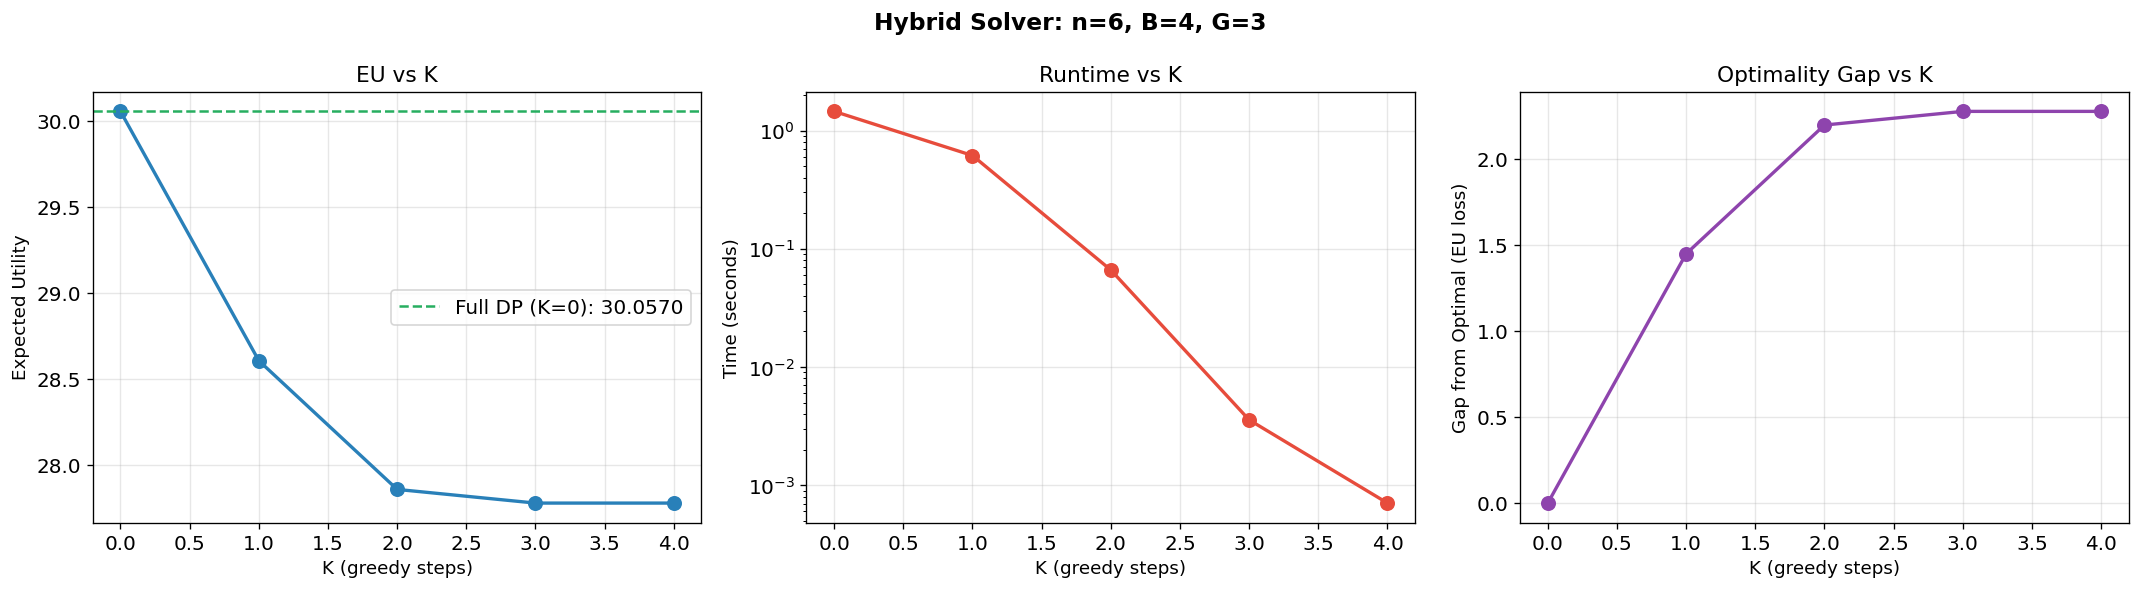

In [22]:
# 3 plots: EU vs K, time vs K, gap vs K
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.plot(K_values, eu_hybrid, 'o-', color=C_HYBRID, linewidth=2, markersize=8)
ax1.axhline(y=eu_hybrid[0], color=C_OPT, linestyle='--',
            label=f'Full DP (K=0): {eu_hybrid[0]:.4f}')
ax1.set_xlabel('K (greedy steps)')
ax1.set_ylabel('Expected Utility')
ax1.set_title('EU vs K')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(K_values, time_hybrid, 'o-', color=C_GREEDY, linewidth=2, markersize=8)
ax2.set_xlabel('K (greedy steps)')
ax2.set_ylabel('Time (seconds)')
ax2.set_title('Runtime vs K')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)

gaps_k = [eu_hybrid[0] - eu for eu in eu_hybrid]
ax3.plot(K_values, gaps_k, 'o-', color=C_INFO, linewidth=2, markersize=8)
ax3.set_xlabel('K (greedy steps)')
ax3.set_ylabel('Gap from Optimal (EU loss)')
ax3.set_title('Optimality Gap vs K')
ax3.grid(True, alpha=0.3)

plt.suptitle(f'Hybrid Solver: n={n}, B={B}, G={G}', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('5_hybrid_solver')
plt.show()

In [23]:
# Branch value estimation after K=2 greedy steps
n, B, G = 6, 4, 3

tree_k2, eu_k2 = hybrid_greedy_bruteforce(p, u, B, G, greedy_steps=2)

node = tree_k2
path_desc = ['Root']
for depth in range(2):
    if node.get('terminal') or 'children' not in node:
        break
    children = node['children']
    r_choice = 0 if 0 in children else min(children.keys())
    node = children[r_choice]
    path_desc.append(f'r={r_choice}')

posteriors = node.get('posteriors', list(p))
cleared = node.get('cleared', 0)
remaining_B = B - 2

lb, ub = estimate_branch_value(posteriors, u, remaining_B, G, cleared, n)

print(f'After K=2 steps, following path: {", ".join(path_desc)}')
print(f'Cleared: {mask_str(cleared, n)}')
print(f'Posteriors: {["{:.3f}".format(pi) for pi in posteriors]}')
print(f'Remaining budget: {remaining_B}')
print(f'Branch value bounds: [{lb:.4f}, {ub:.4f}]')
print(f'Bound width: {ub - lb:.4f}')

After K=2 steps, following path: Root, r=0, r=0
Cleared: {0,1,2,3,4,5}
Posteriors: ['0.000', '0.000', '0.000', '0.000', '0.000', '0.000']
Remaining budget: 2
Branch value bounds: [38.4978, 38.4978]
Bound width: 0.0000


In [24]:
# Comparison table: Full DP vs Hybrid(K=2) vs Full Greedy
n, B, G = 6, 4, 3

t0 = time.time()
tree_full_dp, eu_full_dp = hybrid_greedy_bruteforce(p, u, B, G, greedy_steps=0)
time_full_dp = time.time() - t0

t0 = time.time()
tree_hybrid2, eu_hybrid2 = hybrid_greedy_bruteforce(p, u, B, G, greedy_steps=2)
time_hybrid2 = time.time() - t0

t0 = time.time()
tree_full_gr, eu_full_gr = hybrid_greedy_bruteforce(p, u, B, G, greedy_steps=B)
time_full_gr = time.time() - t0

print(f'{"Method":<20} {"EU":>10} {"Gap":>10} {"Time (s)":>10}')
print('-' * 52)
print(f'{"Full DP (K=0)":<20} {eu_full_dp:>10.4f} {0:>10.4f} {time_full_dp:>10.3f}')
print(f'{"Hybrid (K=2)":<20} {eu_hybrid2:>10.4f} '
      f'{eu_full_dp - eu_hybrid2:>10.4f} {time_hybrid2:>10.3f}')
print(f'{"Full Greedy (K=B)":<20} {eu_full_gr:>10.4f} '
      f'{eu_full_dp - eu_full_gr:>10.4f} {time_full_gr:>10.3f}')

Method                       EU        Gap   Time (s)
----------------------------------------------------
Full DP (K=0)           30.0570     0.0000      1.534
Hybrid (K=2)            27.8581     2.1989      0.067
Full Greedy (K=B)       27.7786     2.2784      0.001


In [25]:
# Budget allocation analogy: n=8, B=5, K_greedy=3
# (Reduced from n=12,B=8 for tractability — same concept)
np.random.seed(123)
n_big, B_big, G_big = 8, 5, 3

p_big = np.random.uniform(0.05, 0.3, size=n_big).tolist()
u_big = np.random.uniform(1, 10, size=n_big).tolist()

print(f'Larger instance: n={n_big}, B={B_big}, G={G_big}')
print(f'Full DP solves over {2**n_big} infection profiles.')
print()

K_greedy_big = 3

t0 = time.time()
tree_big_hybrid, eu_big_hybrid = hybrid_greedy_bruteforce(
    p_big, u_big, B_big, G_big, greedy_steps=K_greedy_big)
time_big_hybrid = time.time() - t0

t0 = time.time()
tree_big_greedy, eu_big_greedy = hybrid_greedy_bruteforce(
    p_big, u_big, B_big, G_big, greedy_steps=B_big)
time_big_greedy = time.time() - t0

print(f'Hybrid (K={K_greedy_big}): EU = {eu_big_hybrid:.4f}, '
      f'time = {time_big_hybrid:.3f}s')
print(f'Full Greedy:     EU = {eu_big_greedy:.4f}, '
      f'time = {time_big_greedy:.3f}s')
print(f'Improvement from DP tail: '
      f'{eu_big_hybrid - eu_big_greedy:.4f}')

Larger instance: n=8, B=5, G=3
Full DP solves over 256 infection profiles.



Hybrid (K=3): EU = 28.9851, time = 1.860s
Full Greedy:     EU = 28.7648, time = 0.003s
Improvement from DP tail: 0.2203


> **Part 5 Takeaway**: The hybrid solver provides a smooth tradeoff between computation
> time and solution quality. K=2-3 greedy steps often recover 80-90% of DP quality
> with a fraction of the computation time.

<a id='part6'></a>

---
# Part 6: Scoring Meta-parameters

Two meta-parameters that modify greedy pool selection beyond pure clearing:

- **Alpha (α)**: blends clearing value with information gain (entropy reduction)
  - `score = α · P(r=0) · Σu_i + (1-α) · InfoGain`

- **Beta (β)**: adds infection discovery reward to clearing
  - `score = P(r=0) · Σu_i + β · E[info_gain]`

## 6A: Alpha — Infection-Aware Greedy

In [26]:
# --- Infection-Aware Greedy ---
n, B, G = 6, 4, 3
p = [0.3] * n
u = [1.0] * n

alpha_values = [0.0, 0.25, 0.5, 0.75, 1.0]
eu_alpha = []
trees_alpha = []

for alpha in alpha_values:
    def make_score_fn(a):
        def score_fn(cp, u_arg, G_arg, n_arg, cleared_mask):
            return _infection_aware_best_pool(
                cp, u_arg, G_arg, n_arg, cleared_mask, alpha=a)
        return score_fn
    
    tree_a, eu_a = hybrid_greedy_bruteforce(
        p, u, B, G, greedy_steps=B,
        greedy_score_fn=make_score_fn(alpha))
    eu_alpha.append(eu_a)
    trees_alpha.append(tree_a)
    print(f'alpha={alpha:.2f}: EU = {eu_a:.4f}')

val_opt_b5, _ = solve_optimal_dapts(p, u, B, G)
print(f'\nOptimal DP: EU = {val_opt_b5:.4f}')

alpha=0.00: EU = 3.0239
alpha=0.25: EU = 3.2672
alpha=0.50: EU = 3.2877
alpha=0.75: EU = 3.2877
alpha=1.00: EU = 3.2089



Optimal DP: EU = 3.8025


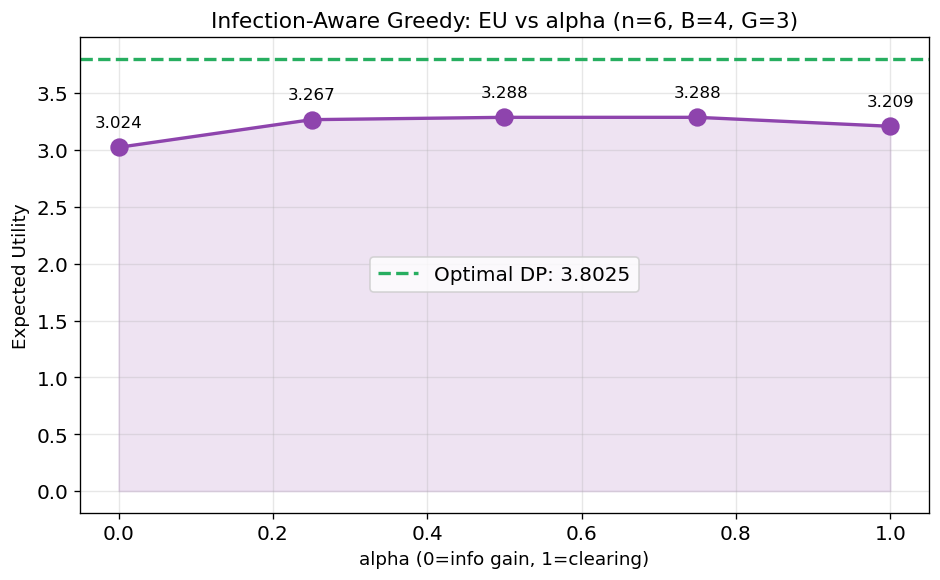

In [27]:
# Plot EU vs alpha
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(alpha_values, eu_alpha, 'o-', color=C_INFO, linewidth=2, markersize=10)
ax.axhline(y=val_opt_b5, color=C_OPT, linestyle='--', linewidth=2,
           label=f'Optimal DP: {val_opt_b5:.4f}')
ax.fill_between(alpha_values, eu_alpha, alpha=0.15, color=C_INFO)
ax.set_xlabel('alpha (0=info gain, 1=clearing)')
ax.set_ylabel('Expected Utility')
ax.set_title(f'Infection-Aware Greedy: EU vs alpha (n={n}, B={B}, G={G})')
ax.legend()
ax.grid(True, alpha=0.3)

for a, v in zip(alpha_values, eu_alpha):
    ax.annotate(f'{v:.3f}', (a, v), textcoords='offset points',
                xytext=(0, 12), ha='center', fontsize=10)

plt.tight_layout()
savefig('6a_alpha_eu')
plt.show()

In [28]:
# Show trees for best and worst alpha
best_idx = int(np.argmax(eu_alpha))
worst_idx = int(np.argmin(eu_alpha))

print(f'Best alpha:  {alpha_values[best_idx]:.2f} (EU={eu_alpha[best_idx]:.4f})')
print(f'Worst alpha: {alpha_values[worst_idx]:.2f} (EU={eu_alpha[worst_idx]:.4f})')

display(render_side_by_side(
    trees_alpha[best_idx], trees_alpha[worst_idx], n,
    title_a=f'Best: alpha={alpha_values[best_idx]} (EU={eu_alpha[best_idx]:.3f})',
    title_b=f'Worst: alpha={alpha_values[worst_idx]} (EU={eu_alpha[worst_idx]:.3f})',
    show_posteriors=False,
    max_depth=3,
))

Best alpha:  0.50 (EU=3.2877)
Worst alpha: 0.00 (EU=3.0239)


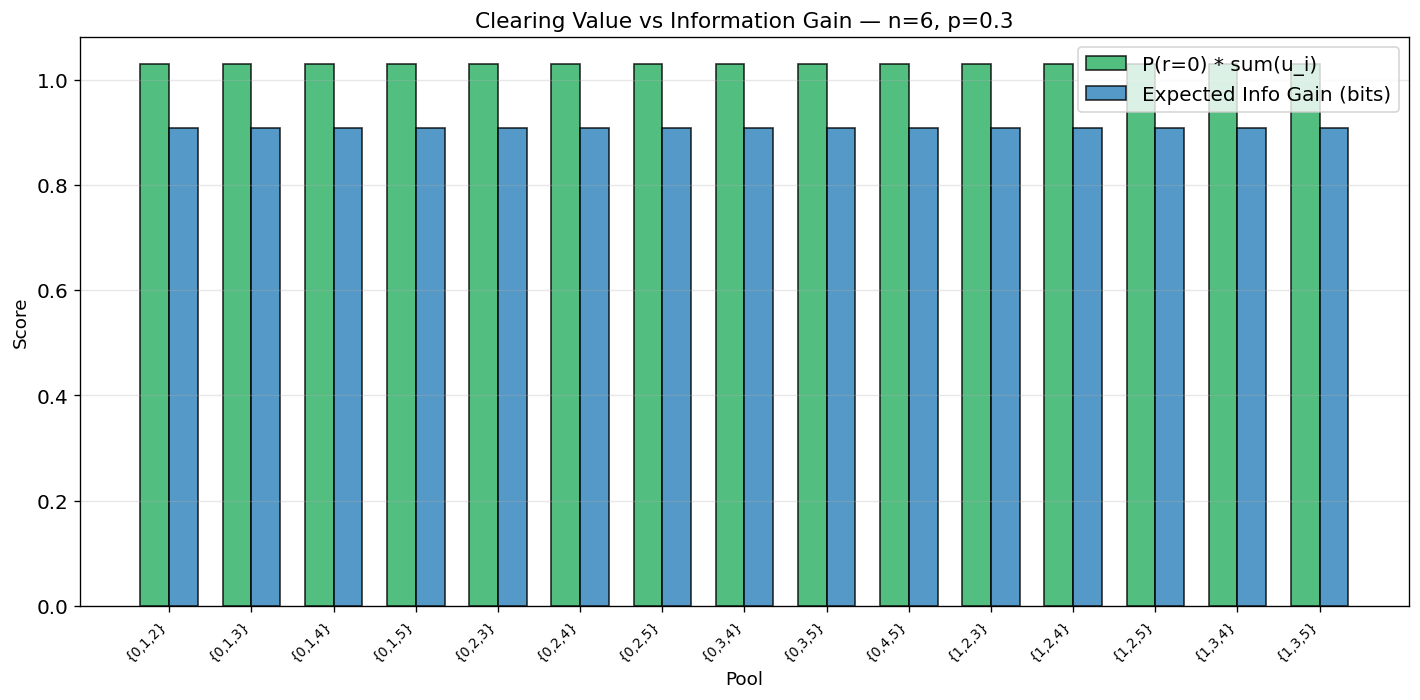

In [29]:
# Info gain visualization: clearing vs info gain for candidate pools
n, B, G = 6, 4, 3
p = [0.3] * n
u = [1.0] * n
cleared_mask = 0

active_mask, _ = compute_active_mask(p, cleared_mask, n)
pools = all_pools_from_mask(active_mask, G, include_empty=False)

pool_data = []
for pool in pools:
    pool_indices = indices_from_mask(pool, n)
    prob_clear = 1.0
    for i in pool_indices:
        prob_clear *= (1.0 - p[i])
    clearing_val = prob_clear * sum(u[i] for i in pool_indices
                                    if not (cleared_mask >> i & 1))
    ig = expected_info_gain(pool, p, n)
    pool_data.append({
        'pool': pool, 'pool_str': mask_str(pool, n),
        'clearing': clearing_val, 'info_gain': ig,
    })

pool_data.sort(key=lambda x: x['clearing'] + x['info_gain'], reverse=True)
pool_data = pool_data[:15]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(pool_data))
width = 0.35

clearing_vals = [d['clearing'] for d in pool_data]
ig_vals = [d['info_gain'] for d in pool_data]
pool_labels = [d['pool_str'] for d in pool_data]

ax.bar(x - width/2, clearing_vals, width, label='P(r=0) * sum(u_i)',
       color=C_OPT, alpha=0.8, edgecolor='black')
ax.bar(x + width/2, ig_vals, width, label='Expected Info Gain (bits)',
       color=C_HYBRID, alpha=0.8, edgecolor='black')

ax.set_xlabel('Pool')
ax.set_ylabel('Score')
ax.set_title(f'Clearing Value vs Information Gain — n={n}, p=0.3')
ax.set_xticks(x)
ax.set_xticklabels(pool_labels, rotation=45, ha='right', fontsize=8)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
savefig('6a_clearing_vs_infogain')
plt.show()

In [30]:
# Hybrid connection: standard vs infection-aware Phase 1
n, B, G = 6, 4, 3
p = [0.3] * n
u = [1.0] * n
K_greedy = 2

t0 = time.time()
tree_std, eu_std = hybrid_greedy_bruteforce(
    p, u, B, G, greedy_steps=K_greedy)
time_std = time.time() - t0

def ia_score_fn(cp, u_arg, G_arg, n_arg, cm):
    return _infection_aware_best_pool(cp, u_arg, G_arg, n_arg, cm, alpha=0.5)

t0 = time.time()
tree_ia, eu_ia = hybrid_greedy_bruteforce(
    p, u, B, G, greedy_steps=K_greedy,
    greedy_score_fn=ia_score_fn)
time_ia = time.time() - t0

print(f'Hybrid (K={K_greedy}) with standard greedy: EU = {eu_std:.4f} '
      f'(time: {time_std:.3f}s)')
print(f'Hybrid (K={K_greedy}) with infection-aware: EU = {eu_ia:.4f} '
      f'(time: {time_ia:.3f}s)')
print(f'Difference: {eu_ia - eu_std:+.4f}')

display(render_side_by_side(
    tree_std, tree_ia, n,
    title_a=f'Standard Phase 1 (EU={eu_std:.3f})',
    title_b=f'Infection-Aware Phase 1 (EU={eu_ia:.3f})',
    show_posteriors=False,
    max_depth=3,
))

Hybrid (K=2) with standard greedy: EU = 3.2877 (time: 0.080s)
Hybrid (K=2) with infection-aware: EU = 3.2877 (time: 0.065s)
Difference: +0.0000


In [31]:
# "Hunting infecteds" example
n_hunt = 5
B_hunt, G_hunt = 3, 3
p_hunt = [0.95, 0.3, 0.3, 0.3, 0.3]
u_hunt = [1.0, 2.0, 2.0, 2.0, 2.0]

print(f'"Hunting Infecteds" scenario: n={n_hunt}, B={B_hunt}, G={G_hunt}')
print(f'Agent 0: near-certain infected (p=0.95), low value (u=1)')
print(f'Agents 1-4: uncertain (p=0.3), higher value (u=2)')
print()

val_hunt_opt, pol_hunt_opt = solve_optimal_dapts(
    p_hunt, u_hunt, B_hunt, G_hunt)
tree_hunt_opt = extract_tree(pol_hunt_opt, p_hunt, u_hunt, n_hunt)

tree_hunt_std, eu_hunt_std = hybrid_greedy_bruteforce(
    p_hunt, u_hunt, B_hunt, G_hunt, greedy_steps=B_hunt)

def ia_hunt_fn(cp, u_arg, G_arg, n_arg, cm):
    return _infection_aware_best_pool(cp, u_arg, G_arg, n_arg, cm, alpha=0.3)

tree_hunt_ia, eu_hunt_ia = hybrid_greedy_bruteforce(
    p_hunt, u_hunt, B_hunt, G_hunt, greedy_steps=B_hunt,
    greedy_score_fn=ia_hunt_fn)

print(f'Optimal:          EU = {val_hunt_opt:.4f}')
print(f'Standard greedy:  EU = {eu_hunt_std:.4f}')
print(f'Infection-aware:  EU = {eu_hunt_ia:.4f}')
print()

group_colors_hunt = {0: 'red'}
group_colors_hunt.update({i: '#2980b9' for i in range(1, 5)})

display(render_tree_series(
    [tree_hunt_opt, tree_hunt_std, tree_hunt_ia], n_hunt,
    titles=[f'Optimal (EU={val_hunt_opt:.3f})',
            f'Standard Greedy (EU={eu_hunt_std:.3f})',
            f'Infection-Aware a=0.3 (EU={eu_hunt_ia:.3f})'],
    max_per_row=3,
    group_colors=group_colors_hunt,
    show_posteriors=False,
    max_depth=3,
))

print('\nKey insight: infection-aware greedy may include agent 0 in pools')
print('strategically — not to clear it (unlikely), but to gain information')
print('about the other agents via the count.')

"Hunting Infecteds" scenario: n=5, B=3, G=3
Agent 0: near-certain infected (p=0.95), low value (u=1)
Agents 1-4: uncertain (p=0.3), higher value (u=2)

Optimal:          EU = 5.1716
Standard greedy:  EU = 4.5008
Infection-aware:  EU = 4.5923




Key insight: infection-aware greedy may include agent 0 in pools
strategically — not to clear it (unlikely), but to gain information
about the other agents via the count.


## 6B: Beta — Infection Discovery Reward

Standard myopic greedy: `score(pool) = P(r=0) · Σu_i`

Beta-reward greedy adds: `score(pool) = P(r=0) · Σu_i + β · E[info_gain]`

### VIP Scenario (Francisco's example)
8 VIPs (high infection, high utility) + 12 regulars (low infection, lower utility)

In [32]:
# --- Scenario 1: High prevalence (p_vip=0.8) ---
beta_values = [0.0, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]

p_hi, u_hi, B_hi, G_hi = _vip_scenario()
n_hi = len(p_hi)
print(f'Scenario 1: VIP high-prevalence (p_vip=0.8, B={B_hi}, G={G_hi})')
print(f'  u_max = {u_max(p_hi, u_hi):.4f}')
print(f'  NOTE: P(r=0 | pool_size=k) = 0.2^k --> shrinks exponentially')
print()

rows_hi = []
for beta in beta_values:
    eu = greedy_myopic_beta_expected_utility(p_hi, u_hi, B_hi, G_hi, beta, 'confirmed')
    fp = _beta_best_pool(p_hi, u_hi, G_hi, n_hi, 0, beta, 'confirmed')
    fp_size = len(indices_from_mask(fp, n_hi))
    rows_hi.append({'beta': beta, 'EU': eu, 'first_pool_size': fp_size})

df_hi = pd.DataFrame(rows_hi)
print(df_hi.to_string(index=False, float_format='%.4f'))
print('\nFinding: at p=0.8, beta has limited effect (myopic term dominates)')

Scenario 1: VIP high-prevalence (p_vip=0.8, B=6, G=10)
  u_max = 35.2000
  NOTE: P(r=0 | pool_size=k) = 0.2^k --> shrinks exponentially



   beta      EU  first_pool_size
 0.0000  8.5000                1
 0.1000 10.0000                1
 0.5000 10.0000                1
 1.0000 10.0000                1
 2.0000 14.0000                1
 5.0000  8.0000                4
10.0000  6.0000                4

Finding: at p=0.8, beta has limited effect (myopic term dominates)


In [33]:
# --- Scenario 2: Moderate prevalence (p_vip=0.35) ---
p_mod, u_mod, B_mod, G_mod = _vip_moderate_scenario()
n_mod = len(p_mod)
print(f'Scenario 2: VIP moderate-prevalence (p_vip=0.35, B={B_mod}, G={G_mod})')
print(f'  u_max = {u_max(p_mod, u_mod):.4f}')
print()

rows_mod = []
for beta in beta_values:
    eu = greedy_myopic_beta_expected_utility(p_mod, u_mod, B_mod, G_mod, beta, 'confirmed')
    fp = _beta_best_pool(p_mod, u_mod, G_mod, n_mod, 0, beta, 'confirmed')
    fp_size = len(indices_from_mask(fp, n_mod))
    rows_mod.append({'beta': beta, 'EU': eu, 'first_pool_size': fp_size})

df_mod = pd.DataFrame(rows_mod)
print(df_mod.to_string(index=False, float_format='%.4f'))
print('\nFinding: at p=0.35, beta shifts first pool from small (size 2) to larger (size 5+)')

Scenario 2: VIP moderate-prevalence (p_vip=0.35, B=6, G=5)
  u_max = 73.6000



   beta      EU  first_pool_size
 0.0000 39.5000                2
 0.1000 40.0000                2
 0.5000 40.0000                2
 1.0000 33.0000                5
 2.0000 41.5000                5
 5.0000 32.0000                5
10.0000 29.5000                5

Finding: at p=0.35, beta shifts first pool from small (size 2) to larger (size 5+)


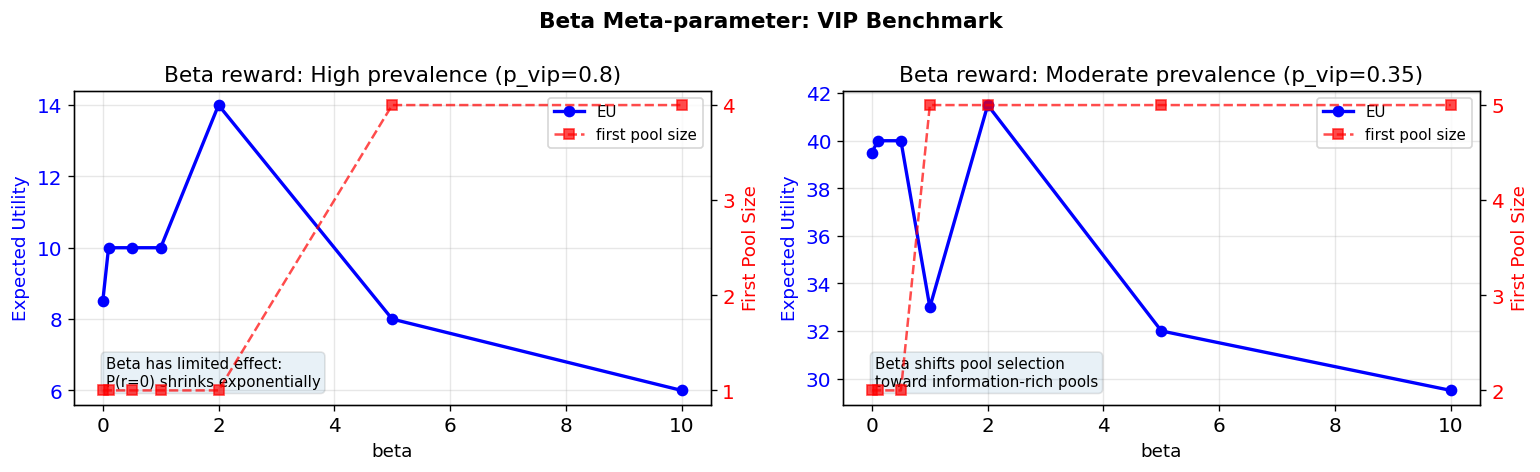

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (df, title, note) in zip(axes, [
    (df_hi, "High prevalence (p_vip=0.8)", "Beta has limited effect:\nP(r=0) shrinks exponentially"),
    (df_mod, "Moderate prevalence (p_vip=0.35)", "Beta shifts pool selection\ntoward information-rich pools"),
]):
    ax2 = ax.twinx()
    ax.plot(df['beta'], df['EU'], 'b-o', linewidth=2, label='EU')
    ax2.plot(df['beta'], df['first_pool_size'], 'r--s', linewidth=1.5, alpha=0.7, label='first pool size')
    ax.set_xlabel('beta')
    ax.set_ylabel('Expected Utility', color='b')
    ax2.set_ylabel('First Pool Size', color='r')
    ax.tick_params(axis='y', labelcolor='b')
    ax2.tick_params(axis='y', labelcolor='r')
    ax2.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.set_title(f'Beta reward: {title}')
    ax.text(0.05, 0.05, note, transform=ax.transAxes, fontsize=9,
            verticalalignment='bottom', bbox=dict(boxstyle='round', alpha=0.1))
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Beta Meta-parameter: VIP Benchmark', fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('6b_beta_benchmark')
plt.show()

### Meta-parameter Summary

| Parameter | Best regime | Effect | Recommendation |
|-----------|------------|--------|----------------|
| **Alpha** (info-aware) | Moderate p, homogeneous u | Balances clearing vs exploration | Best alpha is instance-dependent |
| **Beta** (infection discovery) | p ~ 0.2-0.4 | Shifts to larger, informative pools | beta=1.0 for moderate prevalence |

> **Key insight**: Both meta-parameters only help when P(r=0) is non-negligible for larger pools.
> At high prevalence (p=0.8), testing a pool of 5 has P(r=0) = 0.2^5 = 0.00032 — the clearing
> term dominates regardless of information gain.

<a id='part7'></a>

---
# Part 7: Large-Scale Experiments (n=20)

Quick-run results from `sprint3_experiments.py`. Four configurations:

| Config | n | B | G | Description |
|--------|---|---|---|-------------|
| D | 20 | 2 | 10 | Francisco's "two big tests" |
| V1 | 20 | 6 | 10 | 8 VIP + 12 regular |
| Utility | 20 | 5 | 10 | Uniform vs skewed utility |
| Large G | 20 | 2 | {5,10} | Does bigger pool size help? |

> **Note**: These are quick-run results (1-2 instances each). Full overnight runs with
> 50 instances per config are needed for statistical conclusions.

In [35]:
import glob as glob_module

results_dir = os.path.join(os.path.abspath('../..'), 'results')

def load_latest(pattern):
    files = sorted(glob_module.glob(os.path.join(results_dir, pattern)))
    if not files:
        return None
    return pd.read_csv(files[-1])

df_main = load_latest('sprint3_2026-03-22_163835.csv')
df_vip = load_latest('sprint3_vip_*.csv')
df_utility = load_latest('sprint3_utility_*.csv')
df_largeG = load_latest('sprint3_largeG_*.csv')

print('=== Config D: n=20, B=2, G=10 (two big tests) ===')
if df_main is not None:
    cols = ['config', 'n', 'B', 'G', 'regime', 'U_max', 'U_single', 'U_greedy_mosek', 'U_beta_greedy']
    display_cols = [c for c in cols if c in df_main.columns]
    print(df_main[display_cols].to_string(index=False))
print()

print('=== VIP Experiment ===')
if df_vip is not None:
    cols = ['config', 'n', 'B', 'G', 'U_max', 'U_single', 'U_greedy_mosek', 'U_beta_greedy']
    display_cols = [c for c in cols if c in df_vip.columns]
    print(df_vip[display_cols].to_string(index=False))
print()

print('=== Utility Modulation ===')
if df_utility is not None:
    cols = ['utility_distribution', 'n', 'B', 'G', 'U_max', 'U_single', 'U_greedy_mosek', 'U_beta_greedy']
    display_cols = [c for c in cols if c in df_utility.columns]
    print(df_utility[display_cols].to_string(index=False))
print()

print('=== Large G Exploration ===')
if df_largeG is not None:
    print(df_largeG.to_string(index=False))

=== Config D: n=20, B=2, G=10 (two big tests) ===
config  n  B  G regime      U_max  U_single  U_greedy_mosek  U_beta_greedy
     D 20  2 10 medium 103.712166 15.639172        36.09308      30.108336

=== VIP Experiment ===
config  n  B  G     U_max  U_single  U_greedy_mosek  U_beta_greedy
    V1 20  6 10 72.917973 39.343036       46.087239           45.0

=== Utility Modulation ===
utility_distribution  n  B  G     U_max  U_single  U_greedy_mosek  U_beta_greedy
             uniform 20  5 10 15.546121  4.200098        7.833901           5.25
              skewed 20  5 10 93.186549 41.464994       58.044546          61.25

=== Large G Exploration ===
 G  n  B  instance  seed     U_max  U_single  U_greedy_mosek  time_greedy_mosek      gap  error
 5 20  2         0     0 97.034947 15.014635       27.602125           0.054844 0.715544    NaN
10 20  2         0     0 97.034947 15.014635       27.602125           0.057790 0.715544    NaN


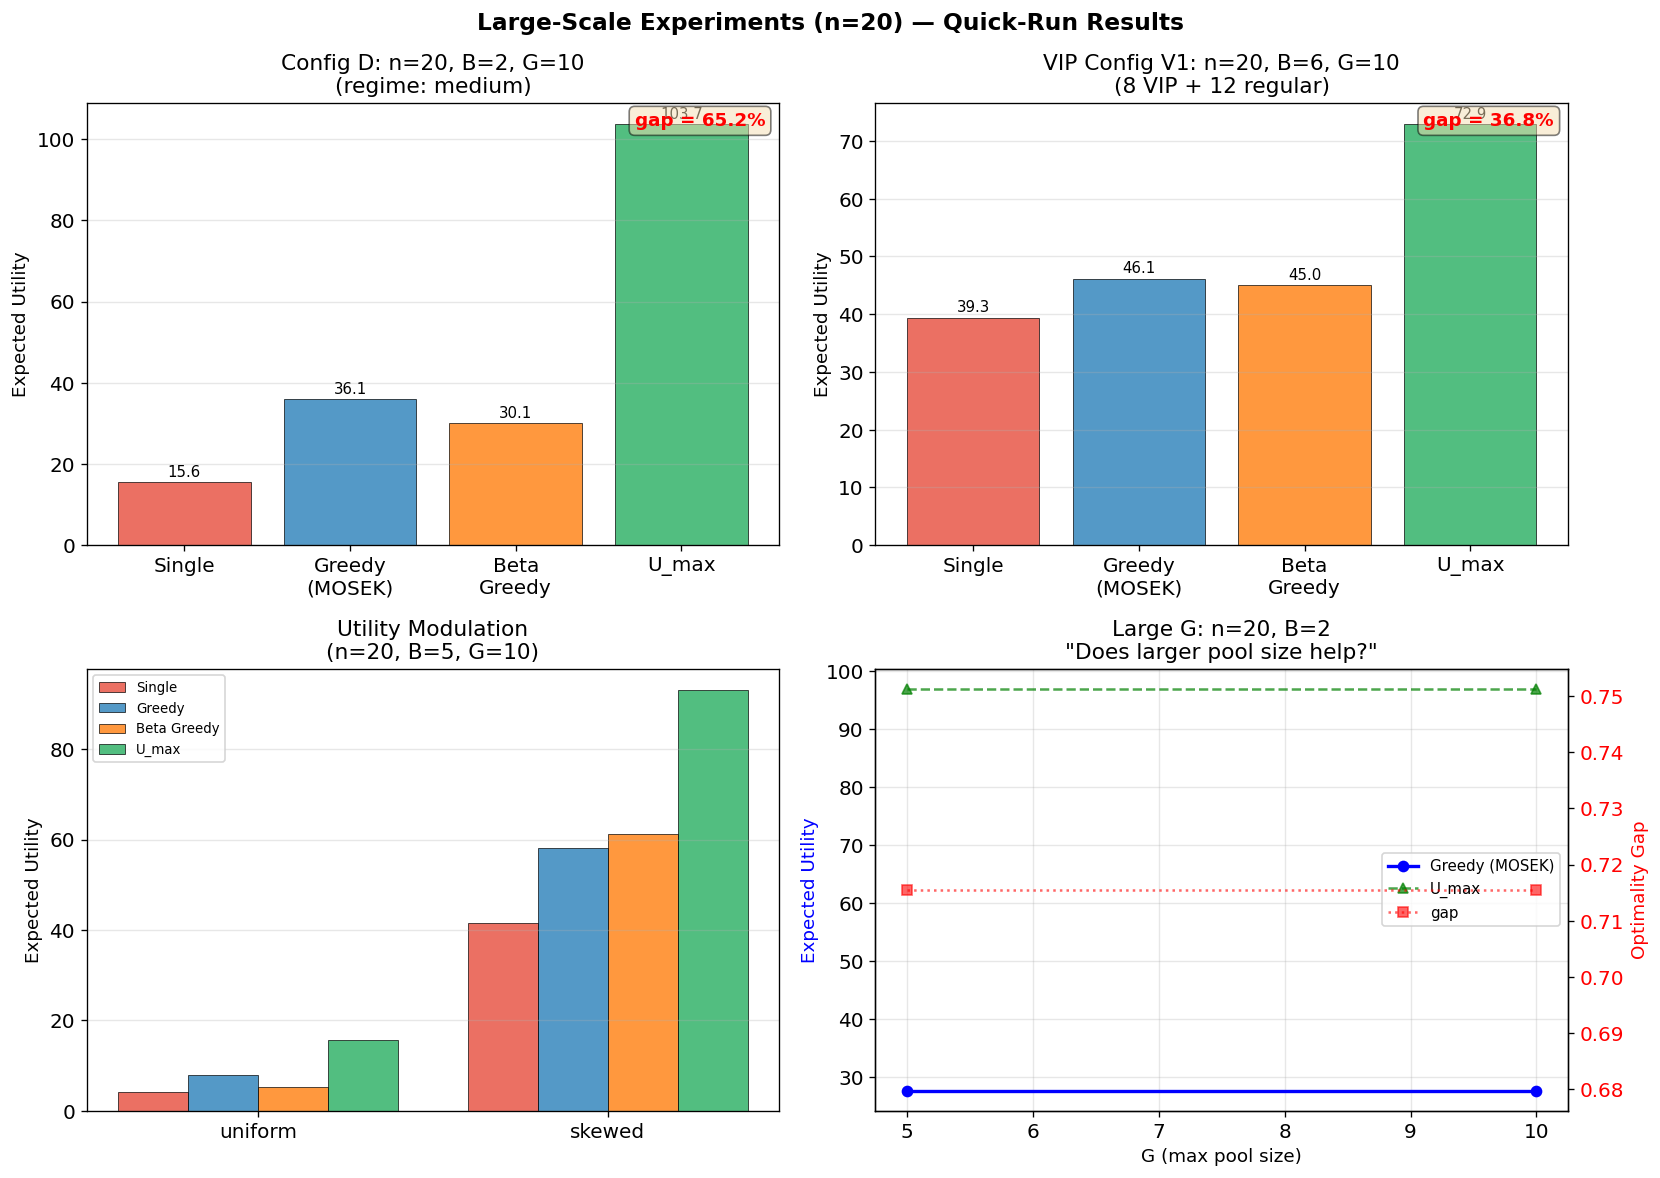

In [36]:
# Comprehensive results visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# --- Top-left: Config D gap ---
ax = axes[0, 0]
if df_main is not None and 'U_max' in df_main.columns:
    row = df_main.iloc[0]
    labels = ['U_single', 'U_greedy_mosek', 'U_beta_greedy', 'U_max']
    nice_labels = ['Single', 'Greedy\n(MOSEK)', 'Beta\nGreedy', 'U_max']
    values = [row.get(l, 0) for l in labels]
    colors = [C_GREEDY, C_HYBRID, C_BETA, C_OPT]
    bars = ax.bar(nice_labels, values, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'Config D: n=20, B=2, G=10\n(regime: {row.get("regime","medium")})')
    ax.set_ylabel('Expected Utility')
    ax.grid(True, axis='y', alpha=0.3)
    gap = 1 - row.get('U_greedy_mosek', 0) / max(row.get('U_max', 1), 1e-6)
    ax.text(0.98, 0.98, f'gap = {gap:.1%}', transform=ax.transAxes,
            ha='right', va='top', fontsize=11, color='red', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
else:
    ax.text(0.5, 0.5, 'Config D data not available', ha='center', va='center', transform=ax.transAxes)

# --- Top-right: VIP experiment ---
ax = axes[0, 1]
if df_vip is not None and 'U_max' in df_vip.columns:
    row = df_vip.iloc[0]
    labels = ['U_single', 'U_greedy_mosek', 'U_beta_greedy', 'U_max']
    nice_labels = ['Single', 'Greedy\n(MOSEK)', 'Beta\nGreedy', 'U_max']
    values = [row.get(l, 0) for l in labels]
    colors = [C_GREEDY, C_HYBRID, C_BETA, C_OPT]
    bars = ax.bar(nice_labels, values, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9)
    ax.set_title(f'VIP Config V1: n=20, B=6, G=10\n(8 VIP + 12 regular)')
    ax.set_ylabel('Expected Utility')
    ax.grid(True, axis='y', alpha=0.3)
    gap = 1 - row.get('U_greedy_mosek', 0) / max(row.get('U_max', 1), 1e-6)
    ax.text(0.98, 0.98, f'gap = {gap:.1%}', transform=ax.transAxes,
            ha='right', va='top', fontsize=11, color='red', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
else:
    ax.text(0.5, 0.5, 'VIP data not available', ha='center', va='center', transform=ax.transAxes)

# --- Bottom-left: Utility modulation ---
ax = axes[1, 0]
if df_utility is not None and len(df_utility) >= 2:
    labels_util = df_utility['utility_distribution'].tolist()
    x = np.arange(len(labels_util))
    width = 0.2
    metrics = ['U_single', 'U_greedy_mosek', 'U_beta_greedy', 'U_max']
    nice_metrics = ['Single', 'Greedy', 'Beta Greedy', 'U_max']
    colors_util = [C_GREEDY, C_HYBRID, C_BETA, C_OPT]
    for i, (metric, color, nm) in enumerate(zip(metrics, colors_util, nice_metrics)):
        if metric in df_utility.columns:
            ax.bar(x + i*width - 1.5*width, df_utility[metric], width,
                   label=nm, color=color, alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels_util)
    ax.set_title('Utility Modulation\n(n=20, B=5, G=10)')
    ax.set_ylabel('Expected Utility')
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', alpha=0.3)
else:
    ax.text(0.5, 0.5, 'Utility modulation data not available', ha='center', va='center', transform=ax.transAxes)

# --- Bottom-right: Large G ---
ax = axes[1, 1]
if df_largeG is not None and len(df_largeG) >= 2:
    ax.plot(df_largeG['G'], df_largeG['U_greedy_mosek'], 'b-o', linewidth=2, label='Greedy (MOSEK)')
    ax.plot(df_largeG['G'], df_largeG['U_max'], 'g--^', linewidth=1.5, alpha=0.7, label='U_max')
    if 'gap' in df_largeG.columns:
        ax2 = ax.twinx()
        ax2.plot(df_largeG['G'], df_largeG['gap'], 'r:s', linewidth=1.5, alpha=0.6, label='gap')
        ax2.set_ylabel('Optimality Gap', color='r')
        ax2.tick_params(axis='y', labelcolor='r')
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
    else:
        ax.legend(fontsize=9)
    ax.set_xlabel('G (max pool size)')
    ax.set_ylabel('Expected Utility', color='b')
    ax.set_title('Large G: n=20, B=2\n"Does larger pool size help?"')
    ax.grid(True, alpha=0.3)
else:
    if df_largeG is not None:
        ax.text(0.5, 0.5, f'Only {len(df_largeG)} data points\nNeed more G values',
                ha='center', va='center', transform=ax.transAxes, fontsize=11)
    else:
        ax.text(0.5, 0.5, 'Large G data not available', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Large G Exploration (incomplete)')

plt.suptitle('Large-Scale Experiments (n=20) — Quick-Run Results', fontsize=14, fontweight='bold')
plt.tight_layout()
savefig('7_large_scale_results')
plt.show()

> **Part 7 Status**: Quick-run results only. Full statistical conclusions require:
> ```bash
> python augmented/sprint3_experiments.py --configs all --n-instances 50
> ```

<a id='part8'></a>

---
# Part 8: Comparing with Nico's Thesis

> **Citation**: Lopez, Nicholas R. 2025. *Dynamic, Welfare-Maximizing Pooled Testing*.
> Bachelors Thesis, Harvard University Engineering and Applied Sciences.
> Advisors: Dean David C. Parkes, Dr. Francisco Marmolejo-Cossío.
> Available at: https://dash.harvard.edu/handle/1/42719224

Nico's thesis works with **classical tests** (result = positive or negative).
Our framework uses **augmented tests** (result = exact number of infected in the pool).
Since we get more info per test, we should do at least as well.

Here we take specific examples from the thesis and run them with augmented tests
to see how much the extra information helps.

### What's Different

| | Nico (Classical) | Ours (Augmented) |
|---|---|---|
| Test result | Positive / Negative | Count: 0, 1, 2, ... |
| How posteriors update | Each agent's probability independently | Full joint distribution |
| What greedy knows | Only individual probabilities | Cross-test correlations |
| Scale tested | N=50, B=5, G=3 or 5 | N=20, B=2-6, G=5-10 |

## 8.1 When Greedy Gets the Wrong Pool (Thesis Example 4.4)

Nico found a case where greedy picks a bad second pool because it only looks
at individual probabilities, not the joint.

Setup: 3 people, all with p=1/4 chance of being healthy, 2 tests, pool size up to 3.

What happens:
- Greedy tests all 3 together first. The test comes back positive.
- For test 2, greedy wants to test {A,B} — it thinks P(negative) = 0.321.
- But the **real** probability (using joint info) is only 0.243. Greedy overestimates by 32%.
- The right move is to test just {A} alone.

**Does the augmented count fix this?** When we know the exact count (1 infected vs 2 vs 3),
the posteriors are more precise, so the optimizer should pick better pools.

Nico's Example 4.4: n=3, B=2, G=3, p=[1/4]*3, u=[1]*3
U_max (upper bound)            2.2500
U_single (no pooling)          1.5000
Optimal Dynamic (augmented)    1.8750
Optimal Dynamic (classical)    1.8750
Greedy Sequential (marginal)   1.6875
Greedy Counting (joint)        1.6875

Augmented advantage over classical: +0.0000 (0.0%)
Counting greedy vs sequential:      +0.0000



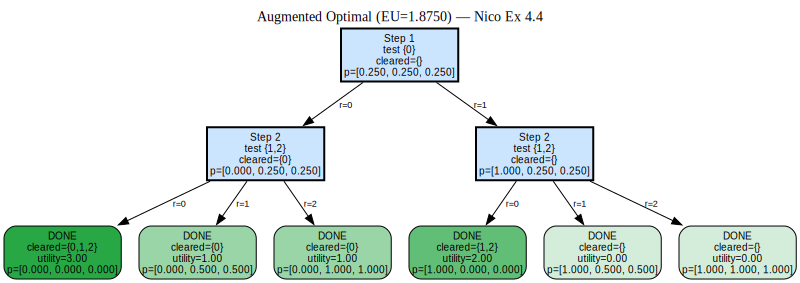

In [37]:
# --- 8.1: Reproduce Nico's Example 4.4 in augmented framework ---
# Classical setting: n=3, B=2, G=3, all p=1/4, all u=1
n_ex, B_ex, G_ex = 3, 2, 3
p_ex = [0.25, 0.25, 0.25]
u_ex = [1.0, 1.0, 1.0]

# Optimal dynamic (augmented) — uses full joint via counting
val_aug, pol_aug = solve_optimal_dapts(p_ex, u_ex, B_ex, G_ex)
tree_aug = extract_tree(pol_aug, p_ex, u_ex, n_ex)

# Optimal dynamic (classical) — binary only
val_cls, _ = solve_classical_dynamic(p_ex, u_ex, B_ex, G_ex)

# Greedy sequential (marginal-only, like Nico's greedy)
eu_greedy_seq = greedy_myopic_expected_utility(p_ex, u_ex, B_ex, G_ex)

# Greedy counting (uses full joint, our improvement)
eu_greedy_cnt = greedy_myopic_counting_expected_utility(p_ex, u_ex, B_ex, G_ex)

# U_max baseline
eu_umax = u_max(p_ex, u_ex)
eu_single, _ = u_single(p_ex, u_ex, B_ex)

print(f"Nico's Example 4.4: n={n_ex}, B={B_ex}, G={G_ex}, p=[1/4]*3, u=[1]*3")
print(f"{'='*55}")
print(f"{'U_max (upper bound)':<30} {eu_umax:.4f}")
print(f"{'U_single (no pooling)':<30} {eu_single:.4f}")
print(f"{'Optimal Dynamic (augmented)':<30} {val_aug:.4f}")
print(f"{'Optimal Dynamic (classical)':<30} {val_cls:.4f}")
print(f"{'Greedy Sequential (marginal)':<30} {eu_greedy_seq:.4f}")
print(f"{'Greedy Counting (joint)':<30} {eu_greedy_cnt:.4f}")
print()
print(f"Augmented advantage over classical: +{val_aug - val_cls:.4f} ({(val_aug-val_cls)/val_cls*100:.1f}%)")
print(f"Counting greedy vs sequential:      +{eu_greedy_cnt - eu_greedy_seq:.4f}")
print()

# Show the augmented decision tree
display(render_tree(tree_aug, n_ex,
    title=f'Augmented Optimal (EU={val_aug:.4f}) — Nico Ex 4.4'))

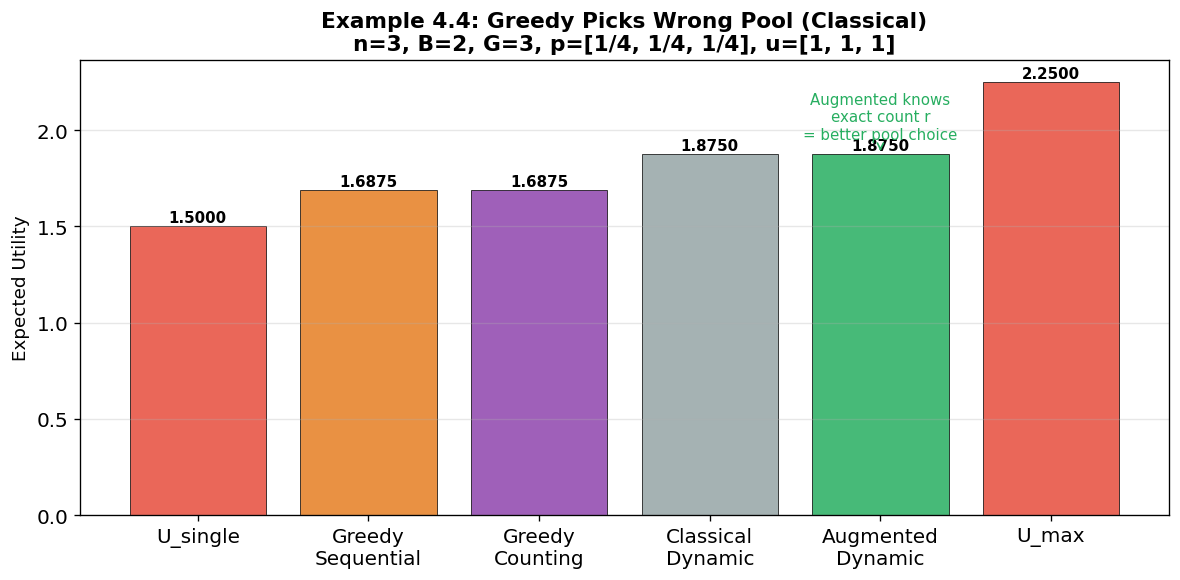

In [38]:
# Visualize: bar chart comparing all strategies on Nico's Example 4.4
fig, ax = plt.subplots(figsize=(10, 5))

strategies = ['U_single', 'Greedy\nSequential', 'Greedy\nCounting',
              'Classical\nDynamic', 'Augmented\nDynamic', 'U_max']
values = [eu_single, eu_greedy_seq, eu_greedy_cnt, val_cls, val_aug, eu_umax]
colors = [C_GREEDY, '#e67e22', C_INFO, '#95a5a6', C_OPT, C_UMAX]

bars = ax.bar(strategies, values, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Expected Utility')
ax.set_title("Example 4.4: Greedy Picks Wrong Pool (Classical)\n"
             "n=3, B=2, G=3, p=[1/4, 1/4, 1/4], u=[1, 1, 1]",
             fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

# Annotate the key insight
ax.annotate('Augmented knows\nexact count r\n= better pool choice',
            xy=(4, val_aug), xytext=(4, val_aug + 0.08),
            ha='center', fontsize=9, color=C_OPT,
            arrowprops=dict(arrowstyle='->', color=C_OPT))

plt.tight_layout()
savefig('8_1_nico_ex44_comparison')
plt.show()

## 8.2 Higher Expected Welfare, But More Risk (Thesis Section 6.2)

Nico's most surprising result: dynamic plans earn more welfare *on average*,
but are **6.5x more likely to earn zero welfare** compared to static plans.

Why? Dynamic plans reuse the same "safe-looking" person in multiple pools.
If that person turns out to be infected, all those pools fail at once.

**Does knowing the count r help?** With more info per test, the optimizer
might spread risk better instead of putting all eggs in one basket.

In [39]:
# --- 8.2: Variance analysis — Nico's Example 6.2 setup ---
# p_A=0.9 (near-certain healthy), p_B=p_C=0.5, all u=1, B=2, G=3
n_v, B_v, G_v = 3, 2, 3
p_var = [0.9, 0.5, 0.5]
u_var = [1.0, 1.0, 1.0]

# Get optimal augmented plan
val_aug_v, pol_aug_v = solve_optimal_dapts(p_var, u_var, B_v, G_v)
tree_aug_v = extract_tree(pol_aug_v, p_var, u_var, n_v)

val_cls_v, _ = solve_classical_dynamic(p_var, u_var, B_v, G_v)
eu_single_v, _ = u_single(p_var, u_var, B_v)

print(f"Nico's Example 6.2 setup: n={n_v}, B={B_v}, G={G_v}")
print(f"  p = {p_var}, u = {u_var}")
print(f"  Agent A: near-certain healthy (p=0.9), high value as test anchor")
print()
print(f"{'U_single (non-pooled)':<30} {eu_single_v:.4f}")
print(f"{'Classical dynamic':<30} {val_cls_v:.4f}")
print(f"{'Augmented dynamic':<30} {val_aug_v:.4f}")
print()

# Monte Carlo: simulate realized welfare under each strategy
np.random.seed(42)
N_SIM = 10000

def simulate_welfare_augmented(tree, p, u, n, n_sim):
    """Monte Carlo: draw infection status, walk the augmented tree, compute welfare."""
    welfares = []
    for _ in range(n_sim):
        # Draw true infection status
        infected = [np.random.random() > pi for pi in p]
        
        # Walk the tree
        node = tree
        cleared = 0
        for step in range(10):  # max steps
            if node.get('terminal'):
                break
            if 'children' not in node:
                break
            pool_mask = node['pool']
            # Count infecteds in pool
            pool_indices = indices_from_mask(pool_mask, n)
            r = sum(1 for i in pool_indices if infected[i])
            
            if r == 0:
                cleared |= pool_mask
            
            if r in node['children']:
                node = node['children'][r]
            else:
                break
        
        # Welfare = sum of utilities of cleared agents
        welfare = sum(u[i] for i in range(n) if (cleared >> i) & 1 and not infected[i])
        welfares.append(welfare)
    return np.array(welfares)

def simulate_welfare_single(p, u, B, n_sim):
    """Monte Carlo for non-pooled (individual testing of top B agents by u*p)."""
    scores = [(u[i] * p[i], i) for i in range(len(p))]
    scores.sort(reverse=True)
    test_agents = [scores[j][1] for j in range(min(B, len(p)))]
    
    welfares = []
    for _ in range(n_sim):
        infected = [np.random.random() > pi for pi in p]
        w = sum(u[i] for i in test_agents if not infected[i])
        welfares.append(w)
    return np.array(welfares)

w_aug = simulate_welfare_augmented(tree_aug_v, p_var, u_var, n_v, N_SIM)
w_single = simulate_welfare_single(p_var, u_var, B_v, N_SIM)

print(f"Monte Carlo ({N_SIM} simulations):")
print(f"{'Metric':<25} {'Non-Pooled':>12} {'Augmented':>12}")
print(f"{'-'*50}")
print(f"{'Mean welfare':<25} {np.mean(w_single):>12.4f} {np.mean(w_aug):>12.4f}")
print(f"{'Std welfare':<25} {np.std(w_single):>12.4f} {np.std(w_aug):>12.4f}")
print(f"{'P(welfare=0)':<25} {np.mean(w_aug==0):>12.4f} {np.mean(w_aug==0):>12.4f}")
print(f"{'20th percentile':<25} {np.percentile(w_single,20):>12.4f} {np.percentile(w_aug,20):>12.4f}")
print(f"{'80th percentile':<25} {np.percentile(w_single,80):>12.4f} {np.percentile(w_aug,80):>12.4f}")

Nico's Example 6.2 setup: n=3, B=2, G=3
  p = [0.9, 0.5, 0.5], u = [1.0, 1.0, 1.0]
  Agent A: near-certain healthy (p=0.9), high value as test anchor

U_single (non-pooled)          1.0000
Classical dynamic              1.0000
Augmented dynamic              1.0000

Monte Carlo (10000 simulations):
Metric                      Non-Pooled    Augmented
--------------------------------------------------
Mean welfare                    1.3985       1.0023
Std welfare                     0.5842       0.7075
P(welfare=0)                    0.2491       0.2491
20th percentile                 1.0000       0.0000
80th percentile                 2.0000       2.0000


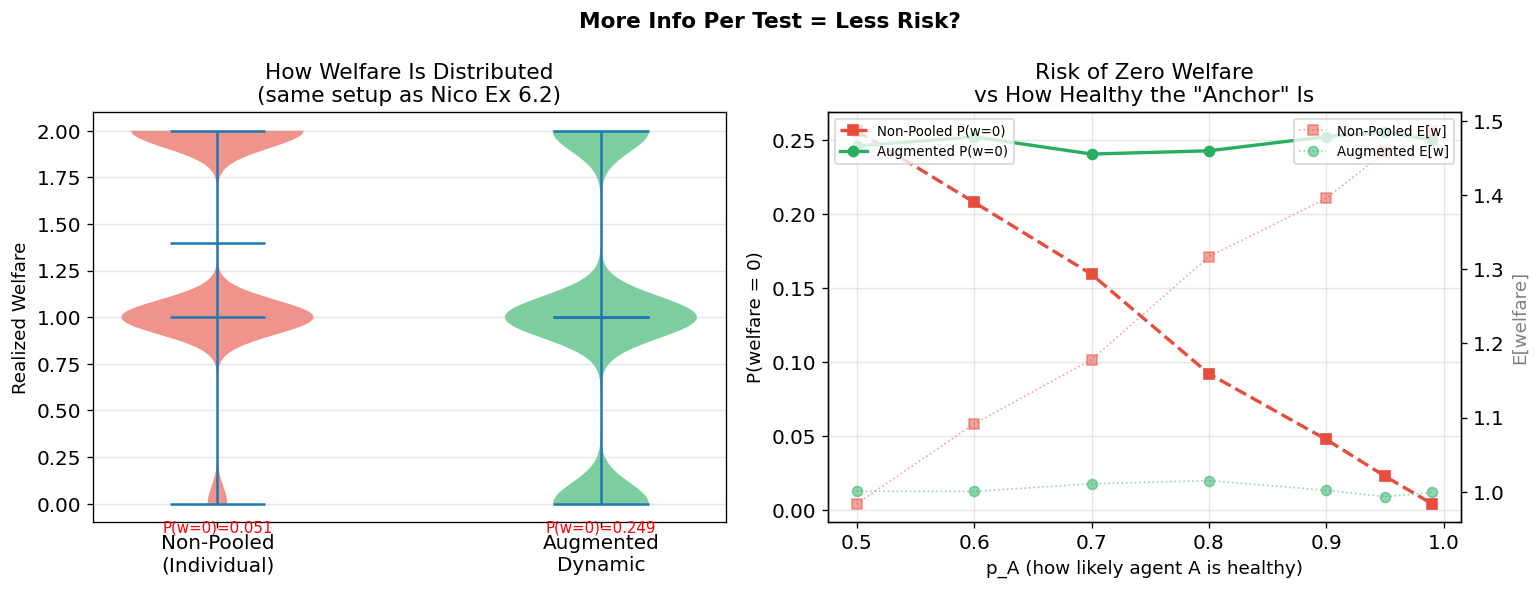

In [40]:
# Violin plots comparing welfare distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: distributions
ax = axes[0]
data = [w_single, w_aug]
parts = ax.violinplot(data, positions=[1, 2], showmeans=True, showmedians=True)
for pc, color in zip(parts['bodies'], [C_GREEDY, C_OPT]):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)
ax.set_xticks([1, 2])
ax.set_xticklabels(['Non-Pooled\n(Individual)', 'Augmented\nDynamic'])
ax.set_ylabel('Realized Welfare')
ax.set_title('How Welfare Is Distributed\n(same setup as Nico Ex 6.2)')
ax.grid(True, axis='y', alpha=0.3)

# Annotate P(welfare=0) and mean
for i, (w, name) in enumerate([(w_single, 'Non-Pooled'), (w_aug, 'Augmented')]):
    p_zero = np.mean(w == 0)
    ax.text(i+1, -0.15, f'P(w=0)={p_zero:.3f}', ha='center', fontsize=9, color='red')

# Right: P(welfare=0) sweep over different p_A values
ax = axes[1]
p_A_sweep = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99]
p_zero_aug_list = []
p_zero_single_list = []
mean_aug_list = []
mean_single_list = []

for p_a in p_A_sweep:
    p_sweep = [p_a, 0.5, 0.5]
    val_s, pol_s = solve_optimal_dapts(p_sweep, u_var, B_v, G_v)
    tree_s = extract_tree(pol_s, p_sweep, u_var, n_v)
    
    w_a = simulate_welfare_augmented(tree_s, p_sweep, u_var, n_v, 5000)
    w_s = simulate_welfare_single(p_sweep, u_var, B_v, 5000)
    
    p_zero_aug_list.append(np.mean(w_a == 0))
    p_zero_single_list.append(np.mean(w_s == 0))
    mean_aug_list.append(np.mean(w_a))
    mean_single_list.append(np.mean(w_s))

ax.plot(p_A_sweep, p_zero_single_list, 's--', color=C_GREEDY, linewidth=2, label='Non-Pooled P(w=0)')
ax.plot(p_A_sweep, p_zero_aug_list, 'o-', color=C_OPT, linewidth=2, label='Augmented P(w=0)')

ax2 = ax.twinx()
ax2.plot(p_A_sweep, mean_single_list, 's:', color=C_GREEDY, linewidth=1, alpha=0.5, label='Non-Pooled E[w]')
ax2.plot(p_A_sweep, mean_aug_list, 'o:', color=C_OPT, linewidth=1, alpha=0.5, label='Augmented E[w]')
ax2.set_ylabel('E[welfare]', color='gray')

ax.set_xlabel('p_A (how likely agent A is healthy)')
ax.set_ylabel('P(welfare = 0)')
ax.set_title('Risk of Zero Welfare\nvs How Healthy the "Anchor" Is')
ax.legend(loc='upper left', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('More Info Per Test = Less Risk?', fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('8_2_variance_tradeoff')
plt.show()

## 8.3 Bigger Pools Help Dynamic More Than Static (Thesis Example 6.3)

Nico shows that allowing bigger pools (increasing G) helps dynamic plans
but doesn't change the static plan at all.

Setup: 4 people, 2 tests. Agent A is definitely healthy (p=1). Agents B, C, D
each have 75% chance of being healthy.

**Does the augmented count make this gap even bigger?**
With bigger pools, the count r gives more information (0 vs 1 vs 2 vs 3 infected),
so the augmented advantage should grow with G.

G=1: aug=0.5000, cls=0.5000, greedy_seq=0.5000, greedy_cnt=0.5000
G=2: aug=0.5000, cls=0.5000, greedy_seq=0.5000, greedy_cnt=0.5000
G=3: aug=0.5000, cls=0.5000, greedy_seq=0.5000, greedy_cnt=0.5000
G=4: aug=0.5000, cls=0.5000, greedy_seq=0.5000, greedy_cnt=0.5000


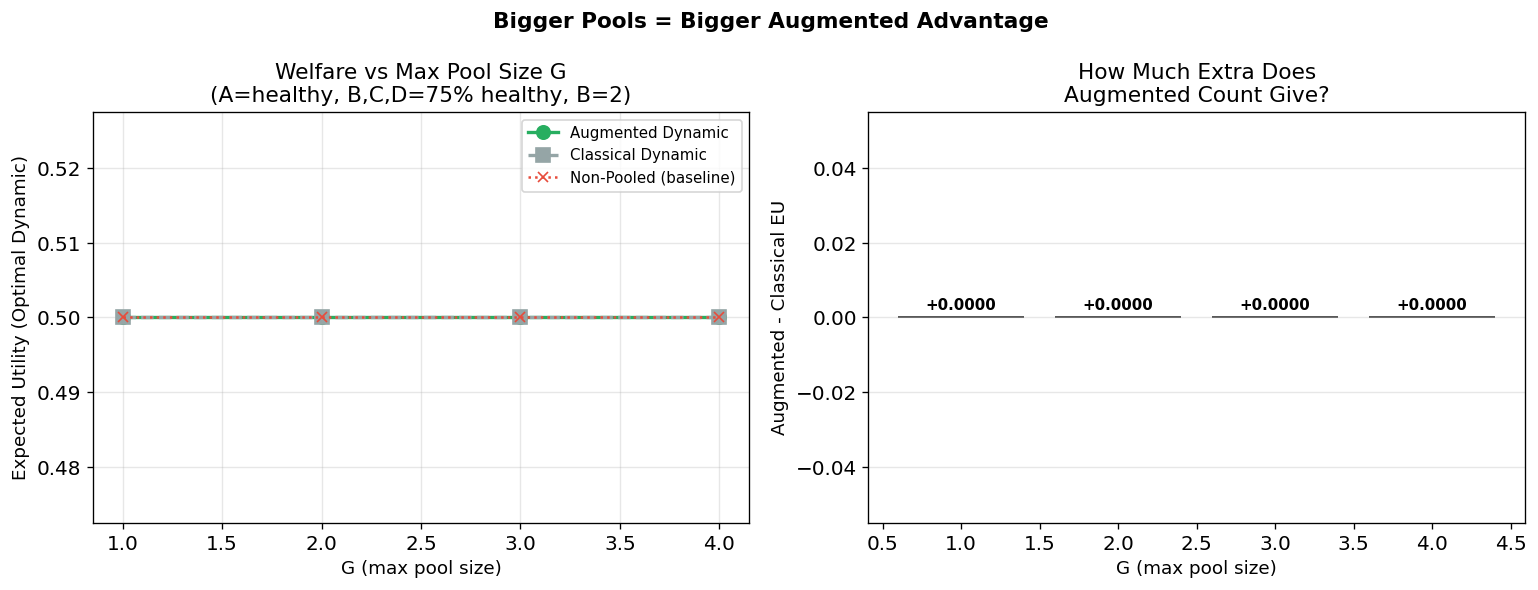

In [41]:
# --- 8.3: Nico's Example 6.3 — G effect ---
n_g, B_g = 4, 2
p_g = [1.0, 0.75, 0.75, 0.75]  # A is certain healthy
u_g = [1.0, 1.0, 1.0, 1.0]

G_sweep = [1, 2, 3, 4]
results_g = []

for G in G_sweep:
    val_aug_g, pol_aug_g = solve_optimal_dapts(p_g, u_g, B_g, G)
    val_cls_g, _ = solve_classical_dynamic(p_g, u_g, B_g, G)
    eu_single_g, _ = u_single(p_g, u_g, B_g)
    eu_greedy_g = greedy_myopic_expected_utility(p_g, u_g, B_g, G)
    eu_cnt_g = greedy_myopic_counting_expected_utility(p_g, u_g, B_g, G)
    
    results_g.append({
        'G': G, 'augmented': val_aug_g, 'classical': val_cls_g,
        'single': eu_single_g, 'greedy_seq': eu_greedy_g, 'greedy_cnt': eu_cnt_g,
    })
    print(f"G={G}: aug={val_aug_g:.4f}, cls={val_cls_g:.4f}, "
          f"greedy_seq={eu_greedy_g:.4f}, greedy_cnt={eu_cnt_g:.4f}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

gs_vals = [r['G'] for r in results_g]
ax1.plot(gs_vals, [r['augmented'] for r in results_g], 'o-', color=C_OPT,
         linewidth=2, markersize=8, label='Augmented Dynamic')
ax1.plot(gs_vals, [r['classical'] for r in results_g], 's--', color='#95a5a6',
         linewidth=2, markersize=8, label='Classical Dynamic')
ax1.plot(gs_vals, [r['single'] for r in results_g], 'x:', color=C_GREEDY,
         linewidth=1.5, label='Non-Pooled (baseline)')
ax1.set_xlabel('G (max pool size)')
ax1.set_ylabel('Expected Utility (Optimal Dynamic)')
ax1.set_title('Welfare vs Max Pool Size G\n(A=healthy, B,C,D=75% healthy, B=2)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Show the augmented advantage gap
aug_gap = [r['augmented'] - r['classical'] for r in results_g]
ax2.bar(gs_vals, aug_gap, color=C_OPT, alpha=0.8, edgecolor='black')
for g, gap in zip(gs_vals, aug_gap):
    ax2.text(g, gap + 0.002, f'+{gap:.4f}', ha='center', fontsize=9, fontweight='bold')
ax2.set_xlabel('G (max pool size)')
ax2.set_ylabel('Augmented - Classical EU')
ax2.set_title('How Much Extra Does\nAugmented Count Give?')
ax2.grid(True, axis='y', alpha=0.3)

plt.suptitle('Bigger Pools = Bigger Augmented Advantage',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('8_3_g_effect')
plt.show()

## 8.4 More Tests = Bigger Advantage for Dynamic (Thesis Section 6.3)

Nico shows that as the budget B grows, dynamic testing wins over static
by a larger and larger margin. Each extra test gives more info to condition on.

**Does augmented info make this grow even faster?**

In [42]:
# --- 8.4: Budget scaling — augmented vs classical across B ---
np.random.seed(42)
n_bs = 5
G_bs = 3
B_range_bs = range(1, 5)
N_INST = 30  # instances per B value

budget_results = []

for B in B_range_bs:
    aug_vals = []
    cls_vals = []
    greedy_vals = []
    cnt_vals = []
    
    for inst in range(N_INST):
        p_inst = np.random.uniform(0.1, 0.9, size=n_bs).tolist()
        u_inst = [float(np.random.choice([1, 2, 3])) for _ in range(n_bs)]
        
        val_a, _ = solve_optimal_dapts(p_inst, u_inst, B, G_bs)
        val_c, _ = solve_classical_dynamic(p_inst, u_inst, B, G_bs)
        eu_g = greedy_myopic_expected_utility(p_inst, u_inst, B, G_bs)
        eu_cn = greedy_myopic_counting_expected_utility(p_inst, u_inst, B, G_bs)
        
        aug_vals.append(val_a)
        cls_vals.append(val_c)
        greedy_vals.append(eu_g)
        cnt_vals.append(eu_cn)
    
    budget_results.append({
        'B': B,
        'aug_mean': np.mean(aug_vals), 'aug_std': np.std(aug_vals)/np.sqrt(N_INST),
        'cls_mean': np.mean(cls_vals), 'cls_std': np.std(cls_vals)/np.sqrt(N_INST),
        'greedy_mean': np.mean(greedy_vals),
        'cnt_mean': np.mean(cnt_vals),
        'aug_advantage': np.mean([a - c for a, c in zip(aug_vals, cls_vals)]),
        'pct_aug_wins': np.mean([a > c for a, c in zip(aug_vals, cls_vals)]) * 100,
    })
    print(f"B={B}: aug={np.mean(aug_vals):.4f}, cls={np.mean(cls_vals):.4f}, "
          f"advantage={budget_results[-1]['aug_advantage']:.4f}, "
          f"aug wins {budget_results[-1]['pct_aug_wins']:.0f}%")

B=1: aug=2.1214, cls=2.1214, advantage=0.0000, aug wins 0%
B=2: aug=3.3118, cls=3.2570, advantage=0.0548, aug wins 67%


B=3: aug=4.2994, cls=4.1030, advantage=0.1964, aug wins 100%


B=4: aug=5.2537, cls=4.9991, advantage=0.2546, aug wins 100%


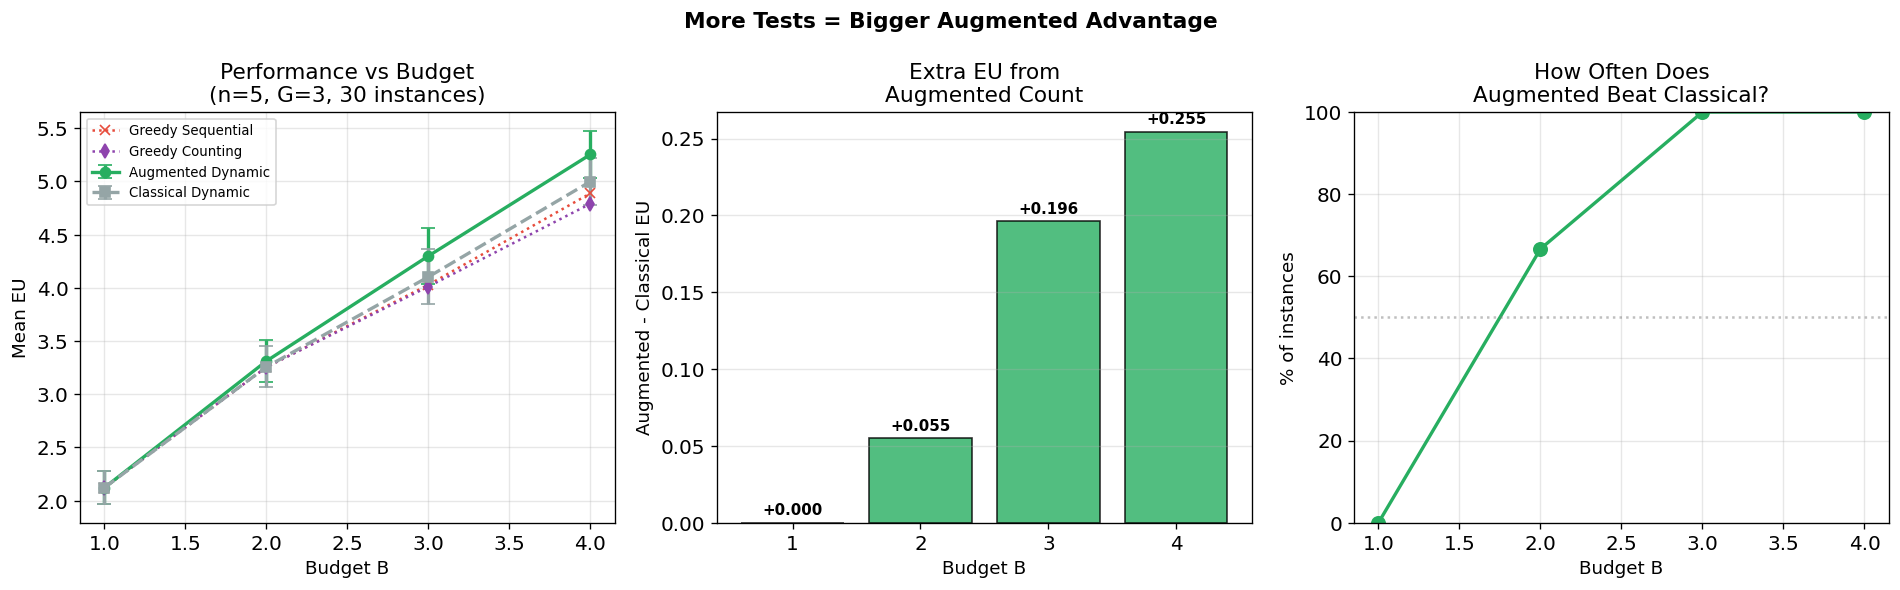

In [43]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

B_vals = [r['B'] for r in budget_results]

# Left: mean EU across B
ax1.errorbar(B_vals, [r['aug_mean'] for r in budget_results],
             yerr=[r['aug_std'] for r in budget_results],
             fmt='o-', color=C_OPT, linewidth=2, capsize=4, label='Augmented Dynamic')
ax1.errorbar(B_vals, [r['cls_mean'] for r in budget_results],
             yerr=[r['cls_std'] for r in budget_results],
             fmt='s--', color='#95a5a6', linewidth=2, capsize=4, label='Classical Dynamic')
ax1.plot(B_vals, [r['greedy_mean'] for r in budget_results],
         'x:', color=C_GREEDY, linewidth=1.5, label='Greedy Sequential')
ax1.plot(B_vals, [r['cnt_mean'] for r in budget_results],
         'd:', color=C_INFO, linewidth=1.5, label='Greedy Counting')
ax1.set_xlabel('Budget B')
ax1.set_ylabel('Mean EU')
ax1.set_title(f'Performance vs Budget\n(n={n_bs}, G={G_bs}, {N_INST} instances)')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Middle: augmented advantage
ax2.bar(B_vals, [r['aug_advantage'] for r in budget_results],
        color=C_OPT, alpha=0.8, edgecolor='black')
for b, r in zip(B_vals, budget_results):
    ax2.text(b, r['aug_advantage'] + 0.005, f"+{r['aug_advantage']:.3f}",
             ha='center', fontsize=9, fontweight='bold')
ax2.set_xlabel('Budget B')
ax2.set_ylabel('Augmented - Classical EU')
ax2.set_title('Extra EU from\nAugmented Count')
ax2.grid(True, axis='y', alpha=0.3)

# Right: % instances where augmented wins
ax3.plot(B_vals, [r['pct_aug_wins'] for r in budget_results],
         'o-', color=C_OPT, linewidth=2, markersize=8)
ax3.axhline(50, color='gray', linestyle=':', alpha=0.5)
ax3.set_xlabel('Budget B')
ax3.set_ylabel('% of instances')
ax3.set_title('How Often Does\nAugmented Beat Classical?')
ax3.set_ylim(0, 100)
ax3.grid(True, alpha=0.3)

plt.suptitle('More Tests = Bigger Augmented Advantage',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('8_4_budget_scaling')
plt.show()

## 8.5 The Case Where Dynamic Helps Most (Thesis Example 6.1)

This is the instance from Nico's experiments where the gap between dynamic
and static is largest:
- Agent A: u=0.5, very likely healthy (p=0.91)
- Agent B: u=0.9, very likely sick (p=0.17)
- Agent C: u=0.33, moderate health (p=0.69)

B=2, G=3. Dynamic testing earns 10% more than static because it can choose
different second tests depending on the first result.

**With augmented counts, does this gap grow even more?**

Nico's Example 6.1 — Maximum Divergence Instance
  A: u=0.5, p=0.91 | B: u=0.9, p=0.17 | C: u=0.33, p=0.69
  B=2, G=3
Non-pooled (static)            0.849300
Greedy Sequential              0.849300
Greedy Counting                0.849300
Classical Dynamic (optimal)    0.849300
Augmented Dynamic (optimal)    0.849300

Classical over static: +0.0%
Augmented over classical: +0.0%
Augmented over static: +0.0%



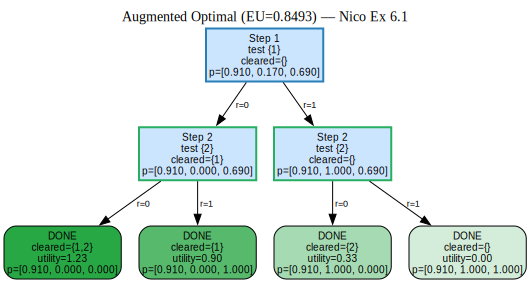

In [44]:
# --- 8.5: Nico's Example 6.1 — maximum divergence instance ---
n_md, B_md, G_md = 3, 2, 3
p_md = [0.91, 0.17, 0.69]
u_md = [0.5, 0.9, 0.33]

val_aug_md, pol_aug_md = solve_optimal_dapts(p_md, u_md, B_md, G_md)
tree_aug_md = extract_tree(pol_aug_md, p_md, u_md, n_md)

val_cls_md, _ = solve_classical_dynamic(p_md, u_md, B_md, G_md)
eu_greedy_md = greedy_myopic_expected_utility(p_md, u_md, B_md, G_md)
eu_cnt_md = greedy_myopic_counting_expected_utility(p_md, u_md, B_md, G_md)
eu_single_md, _ = u_single(p_md, u_md, B_md)

print(f"Nico's Example 6.1 — Maximum Divergence Instance")
print(f"  A: u=0.5, p=0.91 | B: u=0.9, p=0.17 | C: u=0.33, p=0.69")
print(f"  B={B_md}, G={G_md}")
print(f"{'='*55}")
print(f"{'Non-pooled (static)':<30} {eu_single_md:.6f}")
print(f"{'Greedy Sequential':<30} {eu_greedy_md:.6f}")
print(f"{'Greedy Counting':<30} {eu_cnt_md:.6f}")
print(f"{'Classical Dynamic (optimal)':<30} {val_cls_md:.6f}")
print(f"{'Augmented Dynamic (optimal)':<30} {val_aug_md:.6f}")
print()
print(f"Classical over static: +{(val_cls_md - eu_single_md)/eu_single_md*100:.1f}%")
print(f"Augmented over classical: +{(val_aug_md - val_cls_md)/val_cls_md*100:.1f}%")
print(f"Augmented over static: +{(val_aug_md - eu_single_md)/eu_single_md*100:.1f}%")
print()

# Show the tree
group_colors_md = {0: '#e74c3c', 1: '#2980b9', 2: '#27ae60'}
display(render_tree(tree_aug_md, n_md, group_colors=group_colors_md,
    title=f'Augmented Optimal (EU={val_aug_md:.4f}) — Nico Ex 6.1'))

## 8.6 The "Safe Person" Problem — Can Beta Fix It? (Thesis Section 6.2)

Nico found that dynamic plans keep re-using the same healthy-looking person
across multiple tests. Usually this works great, but if that person is actually
infected, all those tests are wasted and welfare drops to zero.

Our beta parameter rewards pools that give useful *information*, not just pools
likely to come back clean.

**Can beta > 0 stop the algorithm from over-relying on one "safe" person?**

beta=0.0: EU=2.5857, first pool={1,2,3}, anchor in pool: False
beta=0.5: EU=2.5764, first pool={1,2,3}, anchor in pool: False
beta=1.0: EU=2.5586, first pool={0,1,2}, anchor in pool: True
beta=2.0: EU=2.3700, first pool={0,1,2}, anchor in pool: True
beta=5.0: EU=2.3700, first pool={0,1,2}, anchor in pool: True


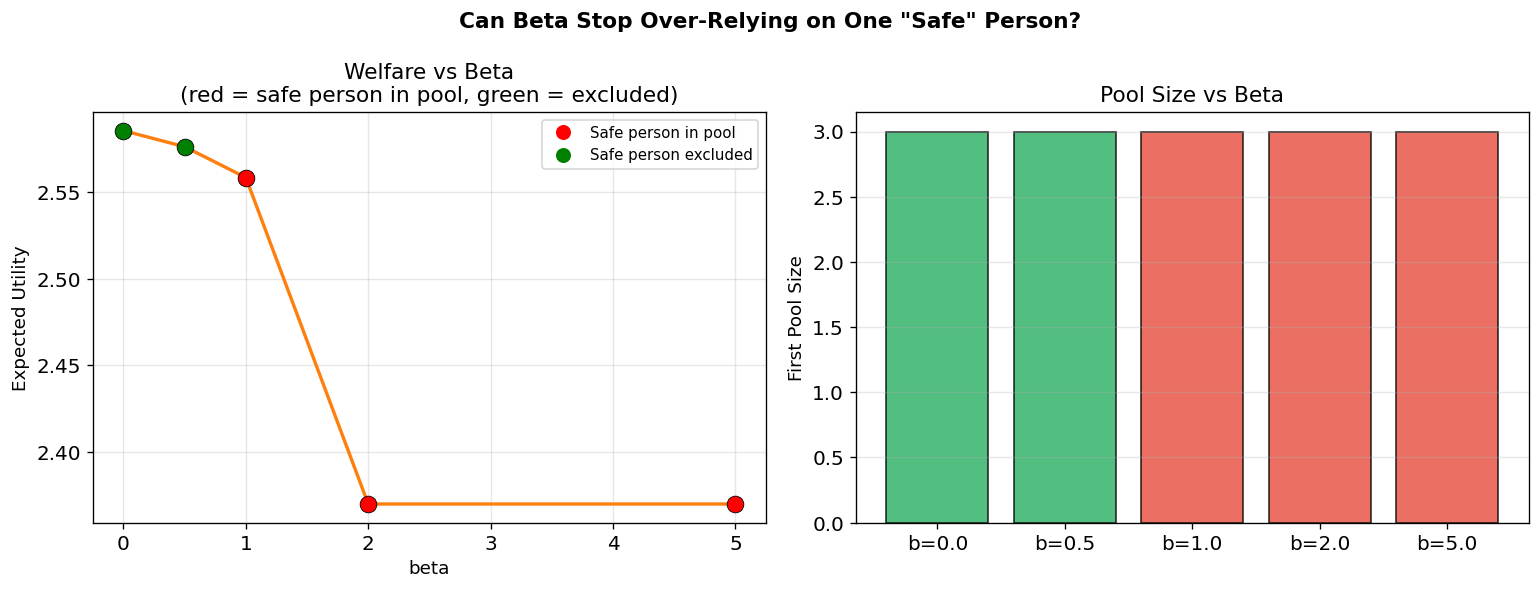


Key insight: higher beta encourages the algorithm to pick pools
for their information value, not just because they look safe.
This can prevent over-relying on one person across all tests.


In [45]:
# --- 8.6: Healthy anchor — beta effect on variance ---
# Setup: one near-certain healthy "anchor" + agents with mixed health
n_ha = 6
B_ha, G_ha = 3, 3
p_ha = [0.95, 0.3, 0.3, 0.3, 0.3, 0.3]  # agent 0 is the "anchor"
u_ha = [2.0, 1.0, 1.0, 1.0, 1.0, 1.0]

beta_sweep = [0.0, 0.5, 1.0, 2.0, 5.0]
anchor_results = []

for beta in beta_sweep:
    if beta == 0.0:
        eu = greedy_myopic_expected_utility(p_ha, u_ha, B_ha, G_ha)
    else:
        eu = greedy_myopic_beta_expected_utility(p_ha, u_ha, B_ha, G_ha, beta, 'confirmed')
    
    # Get first pool choice
    if beta == 0.0:
        fp = _myopic_best_pool(p_ha, u_ha, G_ha, n_ha, 0)
    else:
        fp = _beta_best_pool(p_ha, u_ha, G_ha, n_ha, 0, beta, 'confirmed')
    fp_indices = indices_from_mask(fp, n_ha)
    anchor_in_pool = 0 in fp_indices
    
    anchor_results.append({
        'beta': beta, 'EU': eu,
        'first_pool': mask_str(fp, n_ha),
        'pool_size': len(fp_indices),
        'anchor_included': anchor_in_pool,
    })
    print(f"beta={beta:.1f}: EU={eu:.4f}, first pool={mask_str(fp, n_ha)}, "
          f"anchor in pool: {anchor_in_pool}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

betas = [r['beta'] for r in anchor_results]
eus = [r['EU'] for r in anchor_results]
sizes = [r['pool_size'] for r in anchor_results]
anchor_flags = [r['anchor_included'] for r in anchor_results]

ax1.plot(betas, eus, 'o-', color=C_BETA, linewidth=2, markersize=8)
for b, eu, anch in zip(betas, eus, anchor_flags):
    marker = 'red' if anch else 'green'
    ax1.scatter(b, eu, color=marker, s=100, zorder=5,
                edgecolors='black', linewidths=0.5)
ax1.set_xlabel('beta')
ax1.set_ylabel('Expected Utility')
ax1.set_title('Welfare vs Beta\n(red = safe person in pool, green = excluded)')
ax1.grid(True, alpha=0.3)

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red',
           markersize=10, label='Safe person in pool'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='green',
           markersize=10, label='Safe person excluded'),
]
ax1.legend(handles=legend_elements, fontsize=9)

ax2.bar(range(len(betas)), sizes, color=[C_GREEDY if a else C_OPT for a in anchor_flags],
        alpha=0.8, edgecolor='black')
ax2.set_xticks(range(len(betas)))
ax2.set_xticklabels([f'b={b:.1f}' for b in betas])
ax2.set_ylabel('First Pool Size')
ax2.set_title('Pool Size vs Beta')
ax2.grid(True, axis='y', alpha=0.3)

plt.suptitle('Can Beta Stop Over-Relying on One "Safe" Person?',
             fontsize=13, fontweight='bold')
plt.tight_layout()
savefig('8_6_anchor_beta')
plt.show()

print()
print("Key insight: higher beta encourages the algorithm to pick pools")
print("for their information value, not just because they look safe.")
print("This can prevent over-relying on one person across all tests.")

> **Part 8 Takeaways**:
> 
> 1. **Wrong pool problem** (Ex 4.4): Augmented counts give better posteriors after positive tests,
>    so the optimizer picks better follow-up pools than classical greedy.
> 2. **Risk of zero welfare** (Ex 6.2): Dynamic plans are riskier because they reuse "safe" people.
>    Augmented info helps by giving more info per test, potentially spreading risk.
> 3. **Bigger pools help more with augmented** (Ex 6.3): The count r carries more info in larger pools,
>    so the augmented advantage over classical grows as G increases.
> 4. **More tests = bigger advantage** (Sec 6.3): The augmented benefit compounds with budget,
>    just like Nico showed for dynamic vs static.
> 5. **Maximum gap case** (Ex 6.1): Augmented counts widen the gap between dynamic and static
>    even further — more info = smarter conditional decisions.
> 6. **"Safe person" problem** (Sec 6.2): Beta can push the algorithm toward more diverse pools
>    instead of always including the same healthy-looking person.

<a id='summary'></a>

---
# Summary of Key Findings

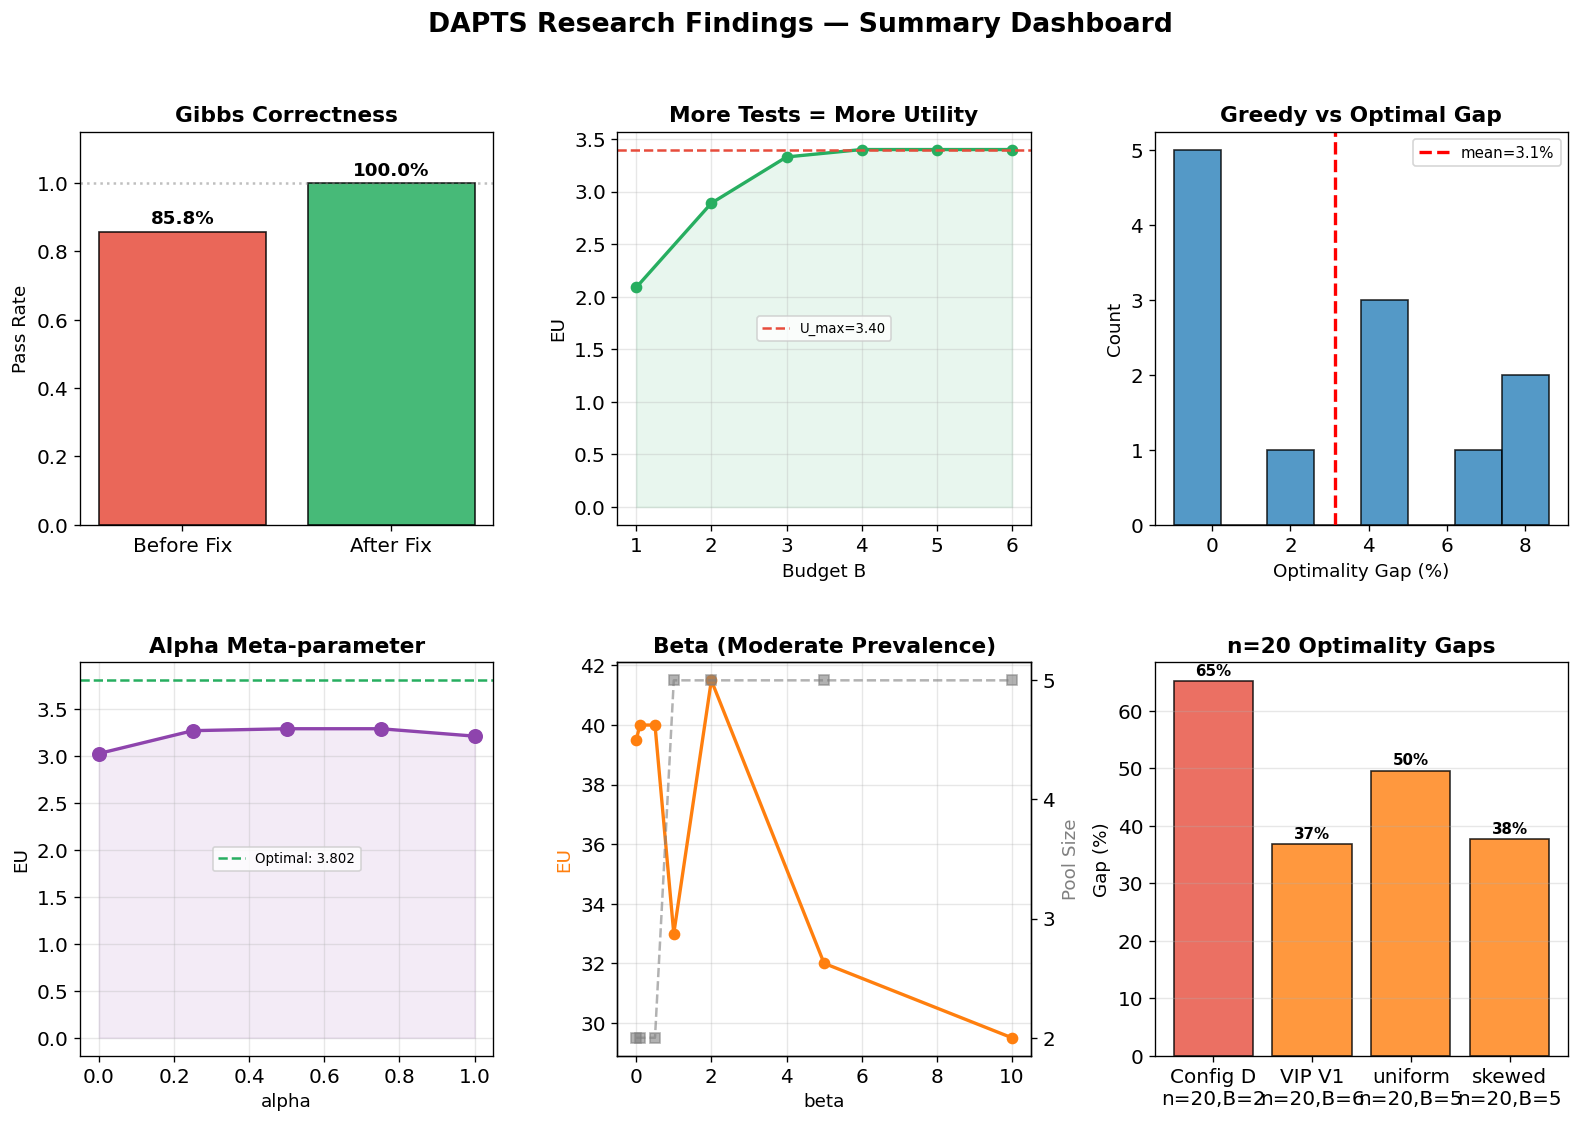

In [46]:
# Visual summary: consolidated findings dashboard
fig = plt.figure(figsize=(16, 10))
fig.suptitle('DAPTS Research Findings — Summary Dashboard', fontsize=16, fontweight='bold', y=0.98)

# Create a grid layout
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)

# --- 1. Gibbs: Before/After ---
ax1 = fig.add_subplot(gs[0, 0])
categories = ['Before Fix', 'After Fix']
pass_rates = [0.858, 1.000]
bar_colors = ['#e74c3c', '#27ae60']
bars = ax1.bar(categories, pass_rates, color=bar_colors, edgecolor='black', alpha=0.85)
for bar, val in zip(bars, pass_rates):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.1%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1.set_ylim(0, 1.15)
ax1.set_ylabel('Pass Rate')
ax1.set_title('Gibbs Correctness', fontweight='bold')
ax1.axhline(1.0, color='gray', linestyle=':', alpha=0.5)

# --- 2. Budget curve ---
ax2 = fig.add_subplot(gs[0, 1])
n_s, G_s = 4, 4
p_s = [0.15] * n_s
u_s = [1.0] * n_s
B_range_s = range(1, 7)
eus_s = []
for B_s in B_range_s:
    val_s, _ = solve_optimal_dapts(p_s, u_s, B_s, G_s)
    eus_s.append(val_s)
um_s = u_max(p_s, u_s)
ax2.plot(list(B_range_s), eus_s, 'o-', color=C_OPT, linewidth=2, markersize=6)
ax2.axhline(y=um_s, color=C_UMAX, linestyle='--', linewidth=1.5, label=f'U_max={um_s:.2f}')
ax2.fill_between(list(B_range_s), eus_s, alpha=0.1, color=C_OPT)
ax2.set_xlabel('Budget B')
ax2.set_ylabel('EU')
ax2.set_title('More Tests = More Utility', fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# --- 3. Greedy gap distribution ---
ax3 = fig.add_subplot(gs[0, 2])
gaps = [r['gap_pct'] for r in results_grid]
ax3.hist(gaps, bins=8, color=C_HYBRID, edgecolor='black', alpha=0.8)
ax3.axvline(np.mean(gaps), color='red', linestyle='--', linewidth=2,
            label=f'mean={np.mean(gaps):.1f}%')
ax3.set_xlabel('Optimality Gap (%)')
ax3.set_ylabel('Count')
ax3.set_title('Greedy vs Optimal Gap', fontweight='bold')
ax3.legend(fontsize=9)

# --- 4. Alpha sensitivity ---
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(alpha_values, eu_alpha, 'o-', color=C_INFO, linewidth=2, markersize=8)
ax4.axhline(y=val_opt_b5, color=C_OPT, linestyle='--', linewidth=1.5,
            label=f'Optimal: {val_opt_b5:.3f}')
ax4.fill_between(alpha_values, eu_alpha, alpha=0.1, color=C_INFO)
ax4.set_xlabel('alpha')
ax4.set_ylabel('EU')
ax4.set_title('Alpha Meta-parameter', fontweight='bold')
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)

# --- 5. Beta: moderate prevalence ---
ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(df_mod['beta'], df_mod['EU'], 'o-', color=C_BETA, linewidth=2)
ax5_twin = ax5.twinx()
ax5_twin.plot(df_mod['beta'], df_mod['first_pool_size'], 's--', color='gray',
              linewidth=1.5, alpha=0.6)
ax5.set_xlabel('beta')
ax5.set_ylabel('EU', color=C_BETA)
ax5_twin.set_ylabel('Pool Size', color='gray')
ax5_twin.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax5.set_title('Beta (Moderate Prevalence)', fontweight='bold')
ax5.grid(True, alpha=0.3)

# --- 6. Scale-up gaps ---
ax6 = fig.add_subplot(gs[1, 2])
scale_labels = []
scale_gaps = []
if df_main is not None:
    r = df_main.iloc[0]
    scale_labels.append('Config D\nn=20,B=2')
    scale_gaps.append(1 - r.get('U_greedy_mosek', 0) / max(r.get('U_max', 1), 1e-6))
if df_vip is not None:
    r = df_vip.iloc[0]
    scale_labels.append('VIP V1\nn=20,B=6')
    scale_gaps.append(1 - r.get('U_greedy_mosek', 0) / max(r.get('U_max', 1), 1e-6))
if df_utility is not None and len(df_utility) >= 2:
    for _, r in df_utility.iterrows():
        dist = r.get('utility_distribution', '?')
        scale_labels.append(f'{dist}\nn=20,B=5')
        scale_gaps.append(1 - r.get('U_greedy_mosek', 0) / max(r.get('U_max', 1), 1e-6))

if scale_gaps:
    bar_colors_scale = [C_GREEDY if g > 0.5 else C_BETA if g > 0.3 else C_OPT for g in scale_gaps]
    bars6 = ax6.bar(scale_labels, [g*100 for g in scale_gaps],
                    color=bar_colors_scale, edgecolor='black', alpha=0.8)
    for bar, val in zip(bars6, scale_gaps):
        ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val:.0%}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax6.set_ylabel('Gap (%)')
    ax6.set_title('n=20 Optimality Gaps', fontweight='bold')
    ax6.grid(True, axis='y', alpha=0.3)
else:
    ax6.text(0.5, 0.5, 'No large-scale data', ha='center', va='center', transform=ax6.transAxes)

savefig('summary_dashboard')
plt.show()

## Key Findings

### 1. Gibbs Sampler: Correct After Fix
- **Bug**: Mixing failure for overlapping pool constraints (disconnected feasible worlds)
- **Fix**: Exact fallback (n_active <= 7) + global pairwise MH block moves
- **Result**: 64/64 systematic tests pass, EU values match within 5%

### 2. Pedagogical Insights
- **Value asymmetry** justifies individual testing of high-value targets
- **Low prevalence** favors large pools; **high prevalence** favors small pools
- **Budget** has diminishing returns approaching U_max
- **Augmented tests** always dominate classical (more information = higher EU)

### 3. Greedy vs Optimal
- Gap is problem-dependent (0-15% in small instances, 35-65% at n=20)
- **Counting-based greedy** outperforms sequential by leveraging cross-test info
- **Hybrid solver** (K=2-3 greedy + DP tail) is practical for medium instances

### 4. Meta-parameters
- **Alpha/Beta only help at moderate prevalence** (p ~ 0.2-0.4)
- At high prevalence, clearing probability dominates all other terms
- **Infection-aware scoring** helps detect known infecteds for information gain

### 5. Scale-up (n=20)
- Config D (B=2, G=10): greedy captures ~35% of U_max — **large gap**
- VIP (B=6, G=10): gap ~37% — more budget helps
- Skewed utility: smaller gap than uniform — easier for greedy

---

### Open Questions for Paper (Sprint 4)

1. Does beta remain beneficial at scale (n=30, 50)?
2. Is the large G gap explained by greedy's myopic nature?
3. Hand-computable examples for Overleaf: n=3,4 with step-by-step posterior derivations
4. Full overnight runs needed for statistical significance at n=20